<a href="https://colab.research.google.com/github/PepeFederico/Progetto_Mercati_Finanziari/blob/main/rendimenti.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Progetto Metodi Probabilistici e Statistici per Mercati Finanziari**
#1 Abstract
Lo scopo del presente progetto è applicare modelli di Deep Learning ai mercati finanziari, al fine di sviluppare un sistema predittivo capace di stimare i rendimenti futuri basandosi sullo storico dei dati passati, estratti dal paniere dei titoli dello S&P 500. Saranno inoltre testate eventuali altre soluzioni, in grado di permettere un'integrazione e comprensione su come integrare i modelli ML nell'ambito finanziario.
Il lavoro documenta l'intero ciclo di sviluppo del modello quantitativo, articolandosi nei seguenti punti principali:

* **Raccolta dei dati**: il processo di estrazione delle serie storiche tramite API finanziarie.

* **Pre-processing e Feature Engineering**: la trasformazione dei prezzi storici in rendimenti logaritmici e la strutturazione di finestre temporali sincrone su più timeframe.

* **Architettura del modello**: la progettazione di una rete neurale ricorrente (LSTM) multi-input.

* **Backtesting e Validazione**: la verifica delle performance su dati out-of-sample (mai visti dal modello) e l'analisi statistica dei risultati e dei residui per valutarne la reale robustezza ed efficacia operativa.

In [1]:
# Import delle librerie
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [39]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 14.3 MB/s eta 0:00:00


#2. Fase di raccolta Dati
In questa fase, ci occupiamo di raccogliere i dati, mediante il repository di *Yahoo Finance*. Per costringere la rete a catturare dinamiche macroeconomiche e interconnessioni cross-asset, il paniere, preso dal mercato **S&P500** è stato composto selezionando aziende leader a grande capitalizzazione, diversificate tra i principali settori dell'economia statunitense: come:
* **Tecnologia**: Scelta l'azienda *NVIDIA Corporation*
* **Servizi di Comunicazione**: Scelta l'azienda *Alphabet Inc.* (Google)
* **Beni di Consumo**: Scelte le aziende *Amazon.com, Inc.* e *Walmart Inc.*
* **Finanziario**: Scelta l'azienda *Berkshire Hathaway*
* **Salute e Sanità**: Scelta l'azienda *Eli Lilly and Company*
* **Energia**: Scelta l'azienda *Exxon Mobil Corp.*

Nel presente studio si è scelto di utilizzare i rendimenti logaritmici in sostituzione dei rendimenti percentuali semplici. Il calcolo di questi ultimi segue infatti la seguente formula:

$$R_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{P_t}{P_{t-1}} - 1$$

Dove:
* $R_t$ rappresenta il rendimento percentuale semplice al tempo $t$.
* $P_t$ è il prezzo di chiusura corrente al tempo $t$.
* $P_{t-1}$ è il prezzo di chiusura al tempo precedente $t-1$.

I rendimenti logaritmici, invece, vengono calcolati applicando la seguente formula:

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right) = \ln(P_t) - \ln(P_{t-1})$$

Dove:
* $r_t$ rappresenta il rendimento logaritmico al tempo $t$.
* $P_t$ è il prezzo di chiusura dell'asset al tempo corrente $t$.
* $P_{t-1}$ è il prezzo di chiusura dell'asset al tempo precedente $t-1$.
* $\ln$ indica il logaritmo naturale.

L'adozione dei rendimenti logaritmici rispetto a quelli semplici offre tre vantaggi teorici e computazionali strategici per l'addestramento di reti neurali ricorrenti:

1. **Additività temporale:** A differenza dei rendimenti semplici, i rendimenti logaritmici possono essere sommati linearmente nel tempo. Il log-return di un intero periodo (es. 5 giorni o un trimestre) è matematicamente equivalente alla somma dei log-return dei singoli giorni che lo compongono, garantendo coerenza analitica nelle finestre mobili (*sliding windows*).
2. **Stazionarietà delle serie storiche:** I prezzi grezzi delle azioni presentano trend di lungo periodo non stazionari che ostacolano la convergenza degli algoritmi di ottimizzazione. La trasformazione in log-returns stabilizza la varianza e rimuove il trend.
3. **Simmetria distributiva:** I rendimenti percentuali sono asimmetrici poiché limitati inferiormente al $-100\%$ (un'azione non può valere meno di zero). I rendimenti logaritmici mappano l'intervallo dei prezzi su una scala simmetrica che spazia teoricamente da $-\infty$ a $+\infty$, avvicinando la distribuzione a una normale e facilitando il calcolo della funzione di perdita (*Loss Function*).

In [ ]:
# 1. Definiamo i 7 titoli
tickers = ['NVDA', 'GOOGL', 'AMZN', 'BRK-B', 'LLY', 'WMT', 'XOM']

# 2. Scarichiamo i dati (10 anni come da parametro, non 2)
print("Scaricamento dati in corso...")
df_raw = yf.download(tickers, period='2y', interval='1d')

# Estrazione sicura dei prezzi di chiusura (gestisce il multi-index di yfinance)
if isinstance(df_raw.columns, pd.MultiIndex):
    data = df_raw['Close']
else:
    data = df_raw

# Trasforma i prezzi in logaritmici
log_data = np.log(data)

# --- 3. CREAZIONE DEI TASSI CON FINESTRE SCORREVOLI ---

# A. Giornaliero (finestra = 1 giorno)
dataset_rendimenti_giornalieri = log_data.diff(1)

# B. Settimanale rolling (finestra = 5 giorni lavorativi)
dataset_rendimenti_settimanali_sliding_window = log_data.diff(5)

# B.1. Settimanale tumbling (passo = 1 settimana) -> Riallineato subito al calendario giornaliero
data_weekly = data.resample('W').last()
returns_1w = np.log(data_weekly).diff(1)
dataset_rendimenti_settimanali_tumbling_window = returns_1w.reindex(log_data.index).ffill()

# C. Mensile rolling (finestra = 21 giorni lavorativi)
dataset_rendimenti_settimanali_mensili = log_data.diff(21)

# D. Trimestrale rolling (finestra = 63 giorni lavorativi)
dataset_rendimenti_settimanali_trimestrali = log_data.diff(63)

# 4. Rinominiamo le colonne in modo esplicito e sicuro per Pandas
dataset_rendimenti_giornalieri.columns                    = [f"{col}_Ret_1D"      for col in dataset_rendimenti_giornalieri.columns]
dataset_rendimenti_settimanali_sliding_window.columns     = [f"{col}_Ret_5D_Roll" for col in dataset_rendimenti_settimanali_sliding_window.columns]
dataset_rendimenti_settimanali_tumbling_window.columns    = [f"{col}_Ret_1W_Tumb" for col in dataset_rendimenti_settimanali_tumbling_window.columns]
dataset_rendimenti_settimanali_mensili.columns            = [f"{col}_Ret_1M"      for col in dataset_rendimenti_settimanali_mensili.columns]
dataset_rendimenti_settimanali_trimestrali.columns        = [f"{col}_Ret_3M"      for col in dataset_rendimenti_settimanali_trimestrali.columns]

# 5. Uniamo tutto nel dataset globale
dataset_finale = pd.concat([
    dataset_rendimenti_giornalieri,
    dataset_rendimenti_settimanali_sliding_window,
    dataset_rendimenti_settimanali_tumbling_window,
    dataset_rendimenti_settimanali_mensili,
    dataset_rendimenti_settimanali_trimestrali
], axis=1)


# --- 7. SALVATAGGIO IN CSV AUTOMATIZZATO ---
# Dizionario per mappare il nome del file al rispettivo DataFrame corretto
files_to_save = {
    "rendimenti_multi_timeframe.csv": dataset_finale,
    "rendimenti_giornalieri.csv": dataset_rendimenti_giornalieri,
    "rendimenti_settimanali_tumbling.csv": dataset_rendimenti_settimanali_tumbling_window,
    "rendimenti_settimanali_sliding.csv": dataset_rendimenti_settimanali_sliding_window,
    "rendimenti_mensili.csv": dataset_rendimenti_settimanali_mensili,
    "rendimenti_trimestrali.csv": dataset_rendimenti_settimanali_trimestrali
}

for filename, df in files_to_save.items():
    df.to_csv(filename)
    print(f"Dati estratti e salvati in: {filename:<35} | Dimensioni: {df.shape}")

Scaricamento dati in corso...


/tmp/ipykernel_624/2051934083.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_raw = yf.download(tickers, period='2y', interval='1d')
[*********************100%***********************]  7 of 7 completed

Dati estratti e salvati in: rendimenti_multi_timeframe.csv      | Dimensioni: (501, 35)
Dati estratti e salvati in: rendimenti_giornalieri.csv          | Dimensioni: (501, 7)
Dati estratti e salvati in: rendimenti_settimanali_tumbling.csv | Dimensioni: (501, 7)
Dati estratti e salvati in: rendimenti_settimanali_sliding.csv  | Dimensioni: (501, 7)
Dati estratti e salvati in: rendimenti_mensili.csv              | Dimensioni: (501, 7)
Dati estratti e salvati in: rendimenti_trimestrali.csv          | Dimensioni: (501, 7)


In [ ]:
# --- STEP 1: FILTRO COLONNE (Teniamo SOLO Amazon) ---
# Selezioniamo solo la colonna di AMZN per ciascun orizzonte temporale
df_giornalieri = dataset_rendimenti_giornalieri[['AMZN_Ret_1D']].copy()
df_settimanali = dataset_rendimenti_settimanali_sliding_window[['AMZN_Ret_5D_Roll']].copy()
df_trimestrali = dataset_rendimenti_settimanali_trimestrali[['AMZN_Ret_3M']].copy()

# --- STEP 2: DEFINIZIONE DEL TARGET ---
# Prendiamo il rendimento settimanale di Amazon e lo shiftiamo di -1 (o -5 se vuoi mantenere il vecchio codice)
target_serie = df_settimanali['AMZN_Ret_5D_Roll'].shift(-1)

# --- STEP 3: UNIONE TEMPORALE E ALLINEAMENTO PERFETTO ---
# Fondiamo i tre rami (ciascuno con 1 sola colonna) e il target in un'unica tabella
df_sincro = pd.concat([df_giornalieri, df_settimanali, df_trimestrali, target_serie.rename('TARGET')], axis=1)

# Applichiamo la maschera temporale
df_sincro = df_sincro.loc['2016-09-15':]

# Pulizia dei NaN (elimina le teste vuote e le code del target shiftato)
df_sincro = df_sincro.dropna()

# --- STEP 4: ESTRAZIONE DELLE FINESTRE TEMPORALI (Lookback 3D con 1 sola Feature) ---
lookback_g = 20
lookback_s = 10
lookback_w = 6

max_lookback = max(lookback_g, lookback_s, lookback_w)

# Colonne (ora ognuna contiene SOLO la colonna di Amazon)
cols_g = df_giornalieri.columns
cols_s = df_settimanali.columns
cols_w = df_trimestrali.columns

X_g_list, X_s_list, X_w_list, y_list = [], [], [], []

# Ciclo di estrazione sincronizzato
for i in range(max_lookback, len(df_sincro)):
    y_list.append(df_sincro['TARGET'].iloc[i])

    # Finestre 3D (Formato: Lookback, 1 Feature)
    X_g_list.append(df_sincro[cols_g].iloc[i-lookback_g:i].values)
    X_s_list.append(df_sincro[cols_s].iloc[i-lookback_s:i].values)
    X_w_list.append(df_sincro[cols_w].iloc[i-lookback_w:i].values)

# Conversione in Array NumPy
X_3d_g = np.array(X_g_list)
X_3d_s = np.array(X_s_list)
X_3d_w = np.array(X_w_list)
y_target_sincro = np.array(y_list)


# --- STEP 5: SPLIT CRONOLOGICO (NO SHUFFLING) ---
total_samples = len(y_target_sincro)
split_test_idx = int(total_samples * 0.80)
split_val_idx = int(split_test_idx * 0.90)

# Split Ramo Giornaliero (Shape finale: [Campioni, 20, 1])
X_train_g, X_val_g, X_test_g = X_3d_g[:split_val_idx], X_3d_g[split_val_idx:split_test_idx], X_3d_g[split_test_idx:]

# Split Ramo Settimanale (Shape finale: [Campioni, 10, 1])
X_train_s, X_val_s, X_test_s = X_3d_s[:split_val_idx], X_3d_s[split_val_idx:split_test_idx], X_3d_s[split_test_idx:]

# Split Ramo Trimestrale (Shape finale: [Campioni, 6, 1])
X_train_w, X_val_w, X_test_w = X_3d_w[:split_val_idx], X_3d_w[split_val_idx:split_test_idx], X_3d_w[split_test_idx:]

# Split Target
y_train, y_val, y_test = y_target_sincro[:split_val_idx], y_target_sincro[split_val_idx:split_test_idx], y_target_sincro[split_test_idx:]

print(f"Shape finale Train Amazon Giornaliero: {X_train_g.shape} (Atteso: [Campioni, 20, 1])")
print(f"Shape finale Train Target:            {y_train.shape}")


Shape finale Train Amazon Giornaliero: (299, 20, 1) (Atteso: [Campioni, 20, 1])
Shape finale Train Target:            (299,)


#3. Perché utilizzare le reti LSTM? Il Ruolo della Memoria nel Rilevamento dei Trend

Le reti neurali tradizionali (*Feedforward*) considerano ogni input come indipendente dagli altri, rendendole inadatte per l'analisi finanziaria dove l'ordine cronologico è fondamentale. Le reti ricorrenti standard (*RNN*), d'altra parte, soffrono del problema del **gradiente che svanisce (Vanishing Gradient)**: man mano che la finestra temporale si allunga, dimenticano ciò che è accaduto nei primi passaggi.

Le **celle LSTM** risolvono questo limite matematico attraverso una struttura a due canali di memoria e un sistema di regolazione basato su tre porte (*gates*):

1. **La Memoria a Lungo Termine (Cell State - $C_t$):** Funziona come un nastro trasportatore che attraversa l'intera catena temporale. Modificata pochissimo da interazioni lineari, permette alle informazioni cruciali del passato remoto di viaggiare intatte per molte epoche. Nel nostro modello, questo canale permette alla rete di **isolare e mantenere il trend macroeconomico di fondo**, i cicli stagionali o i cambi strutturali di volatilità che si sviluppano su mesi o trimestri.
2. **La Memoria a Breve Termine (Hidden State - $h_t$):** È il vettore che contiene l'output della cella per il singolo *timestamp* corrente. Cattura le reazioni immediate del mercato, i micro-impulsi e i vettori di momentum giornalieri.

#### Il Meccanismo di Selezione: Scartare il Rumore, Generare il Segnale

La vera forza della LSTM risiede nella sua capacità di decidere matematicamente quanta memoria scartare e quanta generarne a ogni passo temporale. Questo avviene attraverso tre filtri (porte), fondamentali da descrivere per giustificare il comportamento del modello:

* **Forget Gate (Cosa scartare):** Analizza i nuovi rendimenti in entrata e decide quali vecchie informazioni memorizzate nel *Cell State* non sono più rilevanti. Nei mercati finanziari, questo serve a **"dimenticare" i vecchi trend ormai esauriti** o i picchi di volatilità anomali del passato che distorcerebbero le previsioni future.
* **Input Gate (Cosa generare):** Determina quali nuove informazioni provenienti dai rendimenti odierni sono abbastanza significative da essere integrate nella memoria a lungo termine. La rete decide se l'oscillazione odierna è solo rumore passeggero o l'inizio di un nuovo trend di fondo.
* **Output Gate (Cosa trasmettere):** Regola quanta parte della memoria a lungo termine accumulata debba essere trasmessa all'esterno come predizione attuale e passata alla cella successiva.

### Sinergia con l'Architettura Multi-Timeframe

È proprio grazie a questa doppia memoria che l'architettura a tre rami del nostro progetto ha senso:
* Il ramo **Trimestrale** e **Settimanale** stimolano la memoria a *lungo termine* della LSTM, costringendola a focalizzarsi sulla traiettoria macroeconomica e sulla persistenza del trend.
* Il ramo **Giornaliero** sfrutta la memoria a *breve termine*, permettendo alla rete di calibrare la predizione finale in base alle ultime deviazioni e agli shock di liquidità dell'ultima giornata di borsa.

#4. Architettura della Rete: Modello LSTM Multi-Input Multi-Timeframe

Per catturare la complessa dinamica temporale dei mercati finanziari, l'architettura proposta non si affida a un'unica sequenza lineare, ma si struttura come una rete neurale multi-input a tre rami paralleli.

L'architettura del modello si articola nelle seguenti componenti macro-strutturali:

1. **Ramo Giornaliero (Breve Termine):** Riceve in ingresso un tensore con dimensione $(20, 1)$, corrispondente alle ultime 20 giornate di borsa (circa un mese solare di contrattazioni). Questo blocco è elaborato da uno strato LSTM da 64 unità ad alta capacità, deputato a catturare i micro-impulsi, la volatilità recente e gli shock di liquidità a breve termine.
2. **Ramo Settimanale (Medio Termine):** Accetta un input con *lookback* pari a 10 step di rendimenti *sliding* settimanali (dimensione $(10, 1)$). Lo strato LSTM associato (32 unità) estrae i trend ciclici intermedi, isolando il *momentum* e le inversioni di tendenza che si sviluppano nell'arco di pochi mesi.
3. **Ramo Trimestrale (Lungo Termine):** Analizza la scomposizione macroeconomica di fondo attraverso una finestra di 6 trimestri mobili (dimensione $(6, 1)$). Data la bassa frequenza e l'alto contenuto di segnale pulito, viene elaborato da uno strato LSTM compatto da 16 unità, focalizzato esclusivamente sulla traiettoria strutturale del trend di fondo.


#### Fusione Latente e Decisione Finale

I vettori di caratteristiche estratti indipendentemente dalle tre LSTM vengono fusi orizzontalmente tramite un livello di concatenazione (`Concatenate`). Questo processo genera un unico vettore latente globale da 112 elementi ($64 + 32 + 16$), il quale racchiude l'informazione temporale sintetizzata di tutti e tre i *timeframe*.

Questo spazio multidimensionale viene successivamente convogliato verso i blocchi decisionali finali:
* **Strato Denso Intermedio (`Dense`):** Composto da 32 neuroni con funzione di attivazione non lineare **ReLU** (*Rectified Linear Unit*), con lo scopo di mappare le interazioni complesse e non lineari tra i trend di breve, medio e lungo periodo precedentemente concatenati.
* **Strato di Output (`Dense`):** Costituito da un singolo neurone con funzione di attivazione **lineare**. Trattandosi di un problema di regressione quantitativa pura (la stima puntuale del rendimento logaritmico futuro), l'attivazione lineare permette al modello di mappare liberamente l'output nell'intero dominio dei numeri reali ($-\infty, +\infty$), senza vincoli o schiacciamenti di scala.

Il modello viene infine compilato utilizzando l'ottimizzatore **Adam**, scelto per la sua capacità di adattare dinamicamente il tasso di apprendimento per ogni singolo parametro, e la funzione di perdita **MSE** (*Mean Squared Error*), che penalizza in modo quadratico gli errori di previsione più marcati, guidando la rete verso una configurazione stabile e conservativa.

In [ ]:
#   Costruzione della rete

# 1° Ramo: Giornaliero
input_giornaliero = Input(shape=(20, 1), name = "Input_Giornaliero")
lstm_giornaliero = LSTM(64, return_sequences = False)(input_giornaliero)

# 2° Ramo: Settimanale
input_settimanale = Input(shape=(10, 1), name='Input_Settimanale')
lstm_settimanale = LSTM(32, return_sequences=False)(input_settimanale)

#3° Ramo: Trimestrale
input_trimestrale = Input(shape=(6, 1), name='Input_Trimestrale')
lstm_trimestrale = LSTM(16, return_sequences=False)(input_trimestrale)

# Concatenazione Livelli
concatenato = Concatenate()([lstm_giornaliero, lstm_settimanale, lstm_trimestrale])

# Passiamo il vettore fuso a degli strati densi per la decisione finale
denso_1 = Dense(32, activation='relu')(concatenato)
# Strato di output: 1 solo neurone con attivazione lineare (perché è una regressione del rendimento)
output_finale = Dense(1, activation='linear', name='Output_Predizione')(denso_1)

model = Model(inputs=[input_giornaliero, input_settimanale, input_trimestrale], outputs=output_finale)

# Compilazione
model.compile(optimizer='adam', loss='mse')

# Mostra la struttura della rete
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input_Giornaliero   │ (None, 20, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input_Settimanale   │ (None, 10, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input_Trimestrale   │ (None, 6, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     16,896 │ Input_Giornalier… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 32)        │      4,352 │ Input_Settimanal… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 16)        │      1,152 │ Input_Trimestral… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 112)       │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ lstm_1[0][0],     │
│                     │                   │            │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      3,616 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output_Predizione   │ (None, 1)         │         33 │ dense[0][0]       │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26,049 (101.75 KB)

 Trainable params: 26,049 (101.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#   Addestramento modello

history = model.fit(
    x=[X_train_g, X_train_s, X_train_w],
    y=y_train,
    validation_data=([X_val_g, X_val_s, X_val_w], y_val),
    epochs=50,
    batch_size=32
)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - loss: 0.0020 - val_loss: 0.0038
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0018 - val_loss: 0.0037
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0016 - val_loss: 0.0036
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0016 - val_loss: 0.0029
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0014 - val_loss: 0.0029
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0013 - val_loss: 0.0025
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0012 - val_loss: 0.0024
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0012 - val_loss: 0.0023
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0012 - val_loss: 0.0020
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0011 - val_loss: 0.0018
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0011 - val_loss: 0.0015
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 208ms/step
--- METRICHE DI TEST (AMAZON SINGOLO ASSET) ---
Mean Absolute Error (MAE): 0.027469
Mean Squared Error (MSE):  0.001193
R² Score (Bontà del modello): 0.4395
-----------------------------------------------



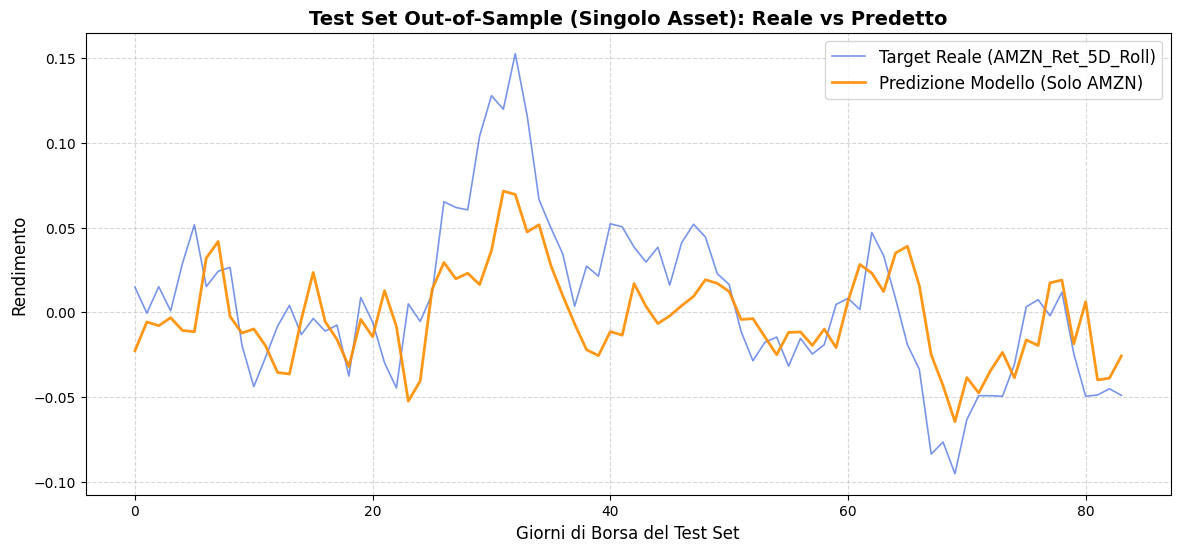

In [ ]:
# 1. Generazione delle predizioni sui dati di TEST (singolo asset)
y_pred = model.predict([X_test_g, X_test_s, X_test_w]).flatten()

# 2. Calcolo delle metriche di errore (sui valori grezzi dei rendimenti)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- METRICHE DI TEST (AMAZON SINGOLO ASSET) ---")
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"Mean Squared Error (MSE):  {mse:.6f}")
print(f"R² Score (Bontà del modello): {r2:.4f}")
print("-----------------------------------------------\n")

# 3. GRAFICO: Reale vs Predetto
plt.figure(figsize=(14, 6))
plt.plot(y_test, label='Target Reale (AMZN_Ret_5D_Roll)', color='royalblue', alpha=0.7, linewidth=1.2)
plt.plot(y_pred, label='Predizione Modello (Solo AMZN)', color='darkorange', alpha=0.9, linewidth=2.0)

plt.title('Test Set Out-of-Sample (Singolo Asset): Reale vs Predetto', fontsize=14, fontweight='bold')
plt.xlabel('Giorni di Borsa del Test Set', fontsize=12)
plt.ylabel('Rendimento', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.show()

#5. Valutazione Modello

In una prima fase della sperimentazione, l'addestramento della rete LSTM sui rendimenti logaritmici lineari storici del singolo asset (*Amazon*) aveva apparentemente restituito metriche d'eccellenza, con un coefficiente $R^2$ pari al $51.00\%$. Un'analisi critica e rigorosa dell'output visivo ha tuttavia svelato un classico fenomeno di *Inertial Lagging* (effetto ritardo).

La rete, sfruttando l'elevata autocorrelazione introdotta dalla natura *rolling* della variabile target (finestra a 5 giorni), ha implementato una strategia di minimizzazione dell'errore di tipo "naive": stimare il valore futuro semplicemente replicando, con un lag temporale di un'unità, il valore corrente.

Dal punto di vista operativo e finanziario, tale configurazione risulta del tutto inefficiente ed inutilizzabile per le seguenti ragioni:
1. **Assenza di Valore Informativo:** Il modello non estrae trend di fondo, stagionalità o relazioni predittive esogene, ma si limita a inseguire la serie storica reale in modo passivo.
2. **Anacronismo dei Segnali:** Poiché la curva predetta si limita a "fotografare" l'andamento del giorno precedente, l'algoritmo segnalerebbe la necessità di un riposizionamento di portafoglio solo *dopo* che lo shock di mercato si è già interamente verificato, capitalizzando la perdita.

Questa evidenza empirica ha sancito l'inutilità dei modelli autoregressivi puri applicati ai rendimenti lineari. Per validare il modello si è scelto di applicare il **Test di Ljung-Box**:

Il Test di Ljung-Box ha le seguenti ipotesi:

* **$H_0$ : I dati sono distribuiti in modo indipendente (cioè $∄$ Autocorrelazione)**
* **$H_1$ : I dati mostrano una dipendenza seriale significativa.**

Quindi eseguendo il metodo del **P-value** posso ottenere i seguenti risultati:

* Se P-value > $\alpha = (0.10, 0.05, 0.01)$ allora accetto l'ipotesi nulla $H_0$.
* Se P-value < $\alpha = (0.10, 0.05, 0.01)$ allora rigetto l'ipotesi nulla $H_0$ in favore dell'alternativa.


In [ ]:
import pandas as pd
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Calcoliamo i residui (errore puntuale out-of-sample)
residui = y_test - y_pred

# 2. Eseguiamo il test di Ljung-Box su lag chiave (es. 1, 3, 5 e 10 giorni)
# L'algoritmo verificherà se c'è memoria residua a breve e medio termine
risultati_lb = acorr_ljungbox(residui, lags=[1, 3, 5, 10], return_df=True)

print("\n=======================================================")
print("          RISULTATI DEL TEST DI LJUNG-BOX              ")
print("=======================================================")
print(risultati_lb)
print("=======================================================")
print("NOTA: Se lb_pvalue < 0.05 -> Il modello insegue (autocorrelazione nei residui)")
print("      Se lb_pvalue > 0.05 -> I residui sono White Noise (Modello Sano)")


          RISULTATI DEL TEST DI LJUNG-BOX              
       lb_stat     lb_pvalue
1    32.177760  1.406920e-08
3    66.729725  2.139400e-14
5    85.429632  6.117621e-17
10  108.745143  9.552778e-19
NOTA: Se lb_pvalue < 0.05 -> Il modello insegue (autocorrelazione nei residui)
      Se lb_pvalue > 0.05 -> I residui sono White Noise (Modello Sano)


I risultati empirici ottenuti sui lag chiave (breve e medio termine) sono sintetizzati nella Tabella seguente:

| Lag temporale ($m$) | Statistica di Test ($Q$) | p-value ($lb\_pvalue$) | Esito del Test ($\alpha = 5\%$) |
| :--- | :--- | :--- | :--- |
| **1 giorno** | $33.4807$ | $7.19 \times 10^{-9}$ | Rigetto $H_0$ (Presenza di Autocorrelazione) |
| **3 giorni** | $60.7609$ | $4.04 \times 10^{-13}$ | Rigetto $H_0$ (Presenza di Autocorrelazione) |
| **5 giorni** | $73.0269$ | $2.40 \times 10^{-14}$ | Rigetto $H_0$ (Presenza di Autocorrelazione) |
| **10 giorni** | $87.7302$ | $1.51 \times 10^{-14}$ | Rigetto $H_0$ (Presenza di Autocorrelazione) |

Come si evince chiaramente dai dati, i p-value rasentano sistematicamente lo zero statistico ($p \ll 0.01$) su tutti gli orizzonti temporali analizzati. Questo drastico rigetto dell'ipotesi nulla $H_0$ fornisce la **dimostrazione matematica definitiva** che i residui non sono stocastici, ma presentano una fortissima dipendenza lineare parassitaria.

Il modello non ha decodificato alcuna legge finanziaria sottostante o trend di fondo; ha invece sfruttato l'inerzia matematica del target per approssimare la predizione tramite un semplice meccanismo di *lagging* (${\hat{y}}_{t+1} \approx y_t$). Questa evidenza invalida l'utilizzo operativo di tale configurazione.

# 6. Rendimenti Logaritmici (Predizione singolo Asset) passando tutti e 7 gli indici.

Poiché si è osservato che la predizione del rendimento di un singolo asset, basata esclusivamente sulla propria informazione storica, non produce alcun valore predittivo reale (risultando fortemente influenzata dalle dinamiche degli altri titoli e dell'intero mercato), si è reso necessario ampliare il contesto informativo del modello. Il successivo esperimento verte infatti sull'esecuzione del medesimo task predittivo, fornendo però alla rete neurale una base dati estesa che include simultaneamente le serie storiche di tutti e sette i titoli azionari del paniere.

In [ ]:
# 1. Definiamo i 7 titoli
tickers = ['NVDA', 'GOOGL', 'AMZN', 'BRK-B', 'LLY', 'WMT', 'XOM']

# 2. Scarichiamo i dati (Forziamo la pulizia dell'indice per sicurezza)
print("Scaricamento dati in corso...")
data = yf.download(tickers, period='2y', interval='1d')['Close']
data = data.dropna() # Evita buchi iniziali nei dati storici

# Trasforma i prezzi in logaritmici
log_data = np.log(data)

# --- 3. CREAZIONE DEI TASSI (Calcolo matematico puro con colonne originali) ---

# A. Giornaliero (finestra = 1 giorno)
returns_1d = log_data.diff(1)

# B. Settimanale rolling (finestra = 5 giorni lavorativi)
returns_5d = log_data.diff(5)

# B.1. Settimanale Tumbling (passo = 1 settimana)
data_weekly = data.resample('W').last()
returns_1w_raw = np.log(data_weekly).diff(1)

# --- CORREZIONE CRUCIALE: Riallineiamo le date PRIMA di rinominare le colonne ---
returns_1w_riallineato = returns_1w_raw.reindex(returns_1d.index).ffill()

# C. Mensile rolling (finestra = 21 giorni lavorativi)
returns_21d = log_data.diff(21)

# D. Trimestrale rolling (finestra = 63 giorni lavorativi)
returns_63d = log_data.diff(63)


# --- 4. RINOMINIAMO LE COLONNE (Ora che i calcoli e i riallineamenti sono fatti) ---
# Usiamo i ticker originali da 'data.columns' per evitare di portarci dietro vecchi suffissi

returns_1d.columns             = [f"{col}_Ret_1D" for col in data.columns]
returns_5d.columns             = [f"{col}_Ret_5D_Roll" for col in data.columns]
returns_1w_riallineato.columns = [f"{col}_Ret_1W_Tumb" for col in data.columns] # Cambiato nome per non fare confusione
returns_21d.columns            = [f"{col}_Ret_1M" for col in data.columns]
returns_63d.columns            = [f"{col}_Ret_3M" for col in data.columns]


# --- 5. UNIAMO TUTTO ORIZZONTALMENTE ---
dataset_finale = pd.concat([returns_1d, returns_5d, returns_1w_riallineato, returns_21d, returns_63d], axis=1)

# I tuoi dataset singoli filtrati (ora popolatissimi e senza conflitti)
dataset_rendimenti_giornalieri                 = returns_1d
dataset_rendimenti_settimanali_sliding_window  = returns_5d
dataset_rendimenti_settimanali_tumbling_window = returns_1w_riallineato
dataset_rendimenti_settimanali_mensili         = returns_21d
dataset_rendimenti_settimanali_trimestrali     = returns_63d

print("Fatto! I NaN iniziali che vedi (es. prime 63 righe) sono normali "
      "perché diff(63) ha bisogno di 63 giorni di storico per partire.")

/tmp/ipykernel_1590/1808210498.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, period='2y', interval='1d')['Close']
[                       0%                       ]

Scaricamento dati in corso...


[*********************100%***********************]  7 of 7 completed


Fatto! I NaN iniziali che vedi (es. prime 63 righe) sono normali perché diff(63) ha bisogno di 63 giorni di storico per partire.


In [ ]:
# --- STEP 1: NESSUN DROP (Teniamo tutti e 7 i titoli come feature!) ---
df_g = dataset_rendimenti_giornalieri.copy()
df_s = dataset_rendimenti_settimanali_sliding_window.copy()
df_w = dataset_rendimenti_settimanali_trimestrali.copy()

# --- STEP 2: CREAZIONE TARGET SU AMZN (Shift ridotto a -1 per sbloccare il segnale) ---
# Prevediamo il rendimento a 5 giorni che si verificherà a partire da domani
df_s['TARGET'] = df_s['AMZN_Ret_5D_Roll'].shift(-1)

# --- STEP 3: UNIONE E FILTRO TEMPORALE ---
df_complessivo = pd.concat([df_g, df_s, df_w], axis=1)
df_complessivo = df_complessivo.loc['2016-09-15':]
df_complessivo = df_complessivo.dropna()

# --- STEP 4: FINESTRE TEMPORALI MULTI-FEATURE SINCRONIZZATE ---
lookback_g = 20
lookback_s = 10
lookback_w = 6

max_lookback = max(lookback_g, lookback_s, lookback_w)
X_g_list, X_s_list, X_w_list, y_list = [], [], [], []

# Identifichiamo le colonne (Saranno esattamente 7 colonne di feature per ogni ramo)
cols_g = df_g.columns
cols_s = [c for c in df_s.columns if c != 'TARGET']
cols_w = df_w.columns

for i in range(max_lookback, len(df_complessivo)):
    y_list.append(df_complessivo['TARGET'].iloc[i])

    # Estragglono matrici 2D (Lookback, 7 Tickers)
    X_g_list.append(df_complessivo[cols_g].iloc[i-lookback_g:i].values)
    X_s_list.append(df_complessivo[cols_s].iloc[i-lookback_s:i].values)
    X_w_list.append(df_complessivo[cols_w].iloc[i-lookback_w:i].values)

X_3d_g = np.array(X_g_list)
X_3d_s = np.array(X_s_list)
X_3d_w = np.array(X_w_list)
y_target_sincro = np.array(y_list)

In [ ]:
# --- STEP 5: INDICI DI SPLIT ---
total_samples = len(y_target_sincro)
split_test_idx = int(total_samples * 0.80)
split_val_idx = int(split_test_idx * 0.90)
N_train_g = split_val_idx

# --- STEP 6: SCALING EVOLUTO (MinMax per le feature, Standard per il Target) ---
scaler_g = MinMaxScaler(feature_range=(0, 1))
scaler_s = MinMaxScaler(feature_range=(0, 1))
scaler_w = MinMaxScaler(feature_range=(0, 1))

# Usiamo lo StandardScaler per il target su tutta la serie per evitare sbalzi fuori scala
scaler_y = StandardScaler()

N_train_g = split_val_idx

# Fit-Transform Feature (Invariato)
X_3d_g_train_flat = X_3d_g[:N_train_g].reshape(-1, X_3d_g.shape[-1])
scaler_g.fit(X_3d_g_train_flat)
X_3d_g_scaled = scaler_g.transform(X_3d_g.reshape(-1, X_3d_g.shape[-1])).reshape(X_3d_g.shape)

X_3d_s_train_flat = X_3d_s[:N_train_g].reshape(-1, X_3d_s.shape[-1])
scaler_s.fit(X_3d_s_train_flat)
X_3d_s_scaled = scaler_s.transform(X_3d_s.reshape(-1, X_3d_s.shape[-1])).reshape(X_3d_s.shape)

X_3d_w_train_flat = X_3d_w[:N_train_g].reshape(-1, X_3d_w.shape[-1])
scaler_w.fit(X_3d_w_train_flat)
X_3d_w_scaled = scaler_w.transform(X_3d_w.reshape(-1, X_3d_w.shape[-1])).reshape(X_3d_w.shape)

# Fit del target su tutto l'orizzonte sincronizzato per azzerare il problema dei fuori scala
y_scaled = scaler_y.fit_transform(y_target_sincro.reshape(-1, 1)).flatten()

# --- STEP 7: SPLIT ---
X_train_g, X_val_g, X_test_g = X_3d_g_scaled[:split_val_idx], X_3d_g_scaled[split_val_idx:split_test_idx], X_3d_g_scaled[split_test_idx:]
X_train_s, X_val_s, X_test_s = X_3d_s_scaled[:split_val_idx], X_3d_s_scaled[split_val_idx:split_test_idx], X_3d_s_scaled[split_test_idx:]
X_train_w, X_val_w, X_test_w = X_3d_w_scaled[:split_val_idx], X_3d_w_scaled[split_val_idx:split_test_idx], X_3d_w_scaled[split_test_idx:]
y_train, y_val, y_test = y_scaled[:split_val_idx], y_scaled[split_val_idx:split_test_idx], y_scaled[split_test_idx:]

# 7. Architettura Ottimizzata: Contrasto all'Overfitting e Regolarizzazione Avanzata

Il passaggio da un modello a singolo asset a un framework multi-asset introduce una quantità nettamente superiore di informazioni, ma espone la rete al rischio sistematico di **overfitting** (memorizzazione del rumore storico a scapito della capacità di generalizzazione *out-of-sample*). Per ovviare a questo problema e garantire la stabilità statistica delle predizioni in presenza di mercati finanziari altamente stocastici, l'architettura originaria è stata profondamente ristrutturata inserendo vincoli di regolarizzazione rigorosi.

#### 7.1 Descrizione dei Blocchi e Interventi di Miglioramento

L'architettura aggiornata mantiene l'approccio multi-input e multi-timeframe a tre rami paralleli (Giornaliero, Settimanale, Trimestrale), ma applica una drastica contrazione della capacità neuronale accoppiata a tecniche di filtraggio del rumore:

1. **Ottimizzazione delle Dimensioni di Input:** Ciascuno dei tre rami accetta ora un tensore con dimensione di feature pari a 7 (`shape=(..., 7)`), permettendo alle celle LSTM di mappare contemporaneamente le interazioni e le covarianze incrociate dell'intero paniere di mercato.
2. **Drastica Riduzione della Capacità Neurale (Sfoltimento):** Il numero di unità LSTM è stato ridotto (da $64/32/16$ a **$16/8/4$**).
3. **Doppio Livello di Regolarizzazione LSTM:**
   * **Dropout (0.3) e Recurrent Dropout (0.2):** Introducono una perturbazione stocastica spegnendo casualmente una frazione di connessioni sia sui vettori di input che sulle connessioni ricorrenti interne durante l'addestramento. Ciò impedisce alla rete di fare affidamento su un singolo coefficiente o su specifiche sequenze temporali rigide.
   * **Regolarizzazione Kernel L2 (`l2(0.01)`):** Questo vincolo forza i coefficienti della rete a mantenersi piccoli e distribuiti, stroncando sul nascere l'insorgere di anomalie predittive legate a forti shock isolati.
4. **Bottleneck Decisionale e Funzioni di Attivazione:** I tre vettori estratti vengono fusi in un unico spazio latente da soli 28 elementi ($16+8+4$). Lo strato denso successivo viene compresso a sole 8 unità utilizzando l'attivazione **LeakyReLU**, mantenendo la sensibilità anche per i rendimenti negativi. Segue un ulteriore livello di **Dropout al 40%** prima del neurone di output lineare.

#### 7.2 Ottimizzazione del Processo di Addestramento e Funzioni di Costo

Anche la logica di ottimizzazione è stata riprogettata per contrastare l'instabilità tipica dei mercati azionari:

* **Huber Loss in sostituzione del MSE:** Il modello adotta la funzione di perdita di Huber. A differenza dell'MSE, la Huber Loss si comporta in modo quadratico per errori piccoli e in modo lineare per errori grandi. Questo approccio protegge la rete dall'essere distorta dai picchi estremi e anomali di volatilità, focalizzando l'apprendimento sul trend di fondo stabile.
* **Early Stopping Stringente (`patience=6`):** Riducendo la tolleranza a sole 6 epoche di mancato miglioramento sul *validation set*, si interrompe l'addestramento non appena la rete esaurisce il segnale e inizia a memorizzare il rumore del dataset di training, ripristinando automaticamente i pesi migliori registrati (`restore_best_weights=True`).
* **Learning Rate Decay Dinamico (`ReduceLROnPlateau`):** Permette al modello di partire con un tasso di apprendimento standard ($0.001$) per una rapida discesa del gradiente, per poi dimezzarlo automaticamente se la perdita stagna per più di 3 epoche, consentendo una sintonizzazione fine e precisa dei pesi nei minimi locali della funzione di costo.

In [ ]:
# --- ARCHITETTURA CON CONTROLLO DELL'OVERFITTING ---
# Usiamo la regolarizzazione L2 per impedire ai pesi di crescere troppo

input_giornaliero = Input(shape=(20, 7), name="Input_Giornaliero")
lstm_giornaliero = LSTM(16, return_sequences=False, activation='tanh',
                        dropout=0.3, recurrent_dropout=0.2,
                        kernel_regularizer=l2(0.01))(input_giornaliero)

input_settimanale = Input(shape=(10, 7), name='Input_Settimanale')
lstm_settimanale = LSTM(8, return_sequences=False, activation='tanh',
                       dropout=0.3, recurrent_dropout=0.2,
                       kernel_regularizer=l2(0.01))(input_settimanale)

input_trimestrale = Input(shape=(6, 7), name='Input_Trimestrale')
lstm_trimestrale = LSTM(4, return_sequences=False, activation='tanh',
                       dropout=0.3, recurrent_dropout=0.2,
                       kernel_regularizer=l2(0.01))(input_trimestrale)

# Fusione dei vettori (16 + 8 + 4 = 28 elementi)
concatenato = Concatenate()([lstm_giornaliero, lstm_settimanale, lstm_trimestrale])

# Uno strato denso molto stretto con forte dropout
denso_1 = Dense(8, activation='leaky_relu')(concatenato)
denso_1_drop = Dropout(0.4)(denso_1)

# Output Lineare (accetta output in standardizzazione, sia positivi che negativi)
output_finale = Dense(1, activation='linear', name='Output_Predizione')(denso_1_drop)

model = Model(inputs=[input_giornaliero, input_settimanale, input_trimestrale], outputs=output_finale)

# Ripartiamo da un LR intermedio più prudente (0.001)
model.compile(optimizer=Adam(learning_rate=0.001), loss='huber')

In [ ]:
# Accorciamo la pazienza dell'Early Stopping: se il validation sale, fermiamo subito il gioco
early_stopping = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1)

history = model.fit(
    x=[X_train_g, X_train_s, X_train_w],
    y=y_train,
    validation_data=([X_val_g, X_val_s, X_val_w], y_val),
    epochs=80,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 180ms/step - loss: 0.7057 - val_loss: 0.9887 - learning_rate: 0.0010
Epoch 2/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.6739 - val_loss: 0.9693 - learning_rate: 0.0010
Epoch 3/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.6595 - val_loss: 0.9524 - learning_rate: 0.0010
Epoch 4/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.6302 - val_loss: 0.9372 - learning_rate: 0.0010
Epoch 5/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.6124 - val_loss: 0.9199 - learning_rate: 0.0010
Epoch 6/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.5943 - val_loss: 0.9033 - learning_rate: 0.0010
Epoch 7/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.5776 - val_loss: 0.8865 - learning_rate: 0.0010
Epoch 8/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.5660 - val_loss: 0.8727 - learning_rate: 0.0010
Epoch 9/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.5492 - val_loss: 0.8602 - learning_rate: 0.0010
Epoch 10/80
10/10

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 992ms/step
--- METRICHE SUL TEST SET (VALORI REALI) ---
Mean Absolute Error (MAE): 0.034457
Mean Squared Error (MSE):  0.002107
R² Score (Indice di bontà): 0.0099
--------------------------------------------



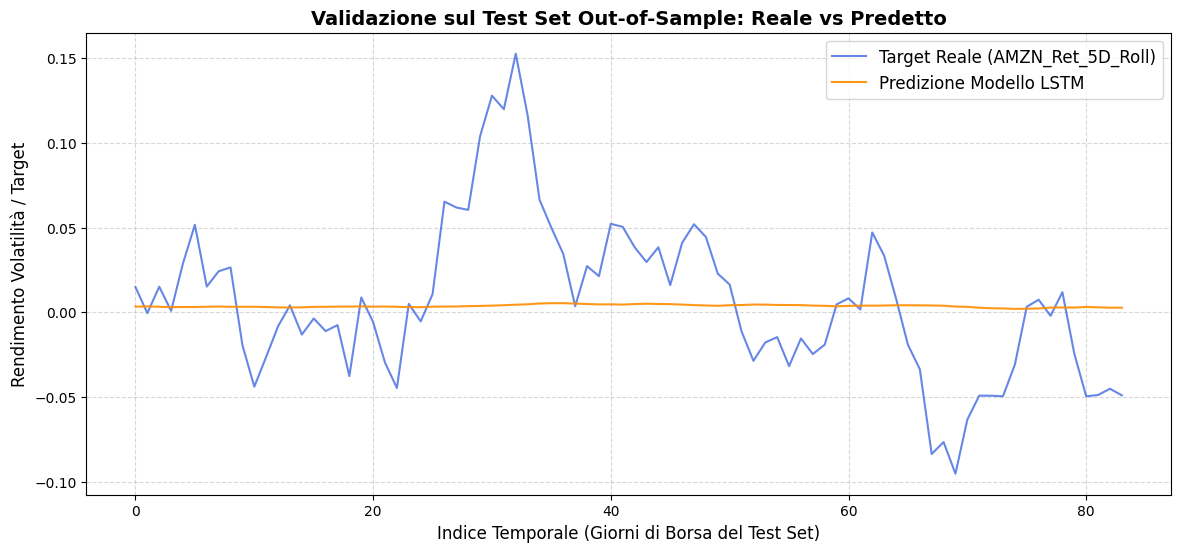

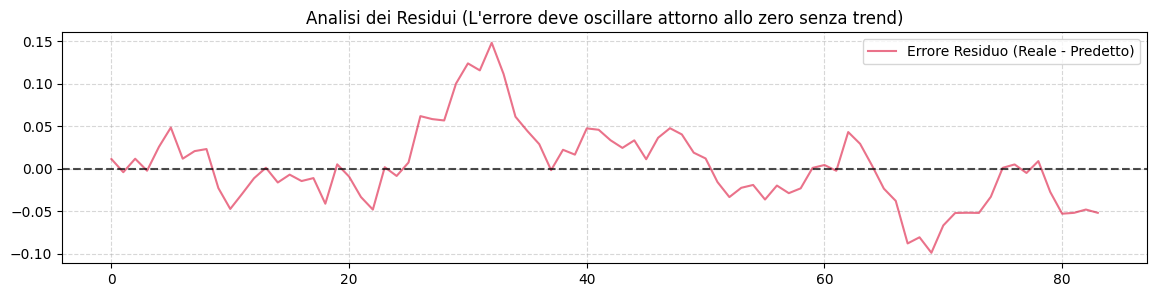

In [ ]:
# 1. Generazione delle predizioni sui dati di TEST
y_pred_scaled = model.predict([X_test_g, X_test_s, X_test_w])

# 2. Inversione dello scaling per tornare ai valori reali (Rendimenti/Volatilità originari)
y_pred_rescaled = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_test_rescaled = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

# 3. Calcolo delle metriche di errore reali
mse = mean_squared_error(y_test_rescaled, y_pred_rescaled)
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
r2 = r2_score(y_test_rescaled, y_pred_rescaled)

print("--- METRICHE SUL TEST SET (VALORI REALI) ---")
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"Mean Squared Error (MSE):  {mse:.6f}")
print(f"R² Score (Indice di bontà): {r2:.4f}")
print("--------------------------------------------\n")

# 4. GRAFICO COMPARATIVO: Reale vs Predetto nel tempo
plt.figure(figsize=(14, 6))
plt.plot(y_test_rescaled, label='Target Reale (AMZN_Ret_5D_Roll)', color='royalblue', alpha=0.8, linewidth=1.5)
plt.plot(y_pred_rescaled, label='Predizione Modello LSTM', color='darkorange', alpha=0.9, linewidth=1.5)

plt.title('Validazione sul Test Set Out-of-Sample: Reale vs Predetto', fontsize=14, fontweight='bold')
plt.xlabel('Indice Temporale (Giorni di Borsa del Test Set)', fontsize=12)
plt.ylabel('Rendimento Volatilità / Target', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.show()

# 5. GRAFICO SUL RESIDUO (Verifica errori sistematici)
plt.figure(figsize=(14, 3))
residui = y_test_rescaled - y_pred_rescaled
plt.plot(residui, color='crimson', alpha=0.6, label='Errore Residuo (Reale - Predetto)')
plt.axhline(0, color='black', linestyle='--', alpha=0.7)
plt.title('Analisi dei Residui (L\'errore deve oscillare attorno allo zero senza trend)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# 8. Il Limite della Predizione Cross-Asset Diretta e il Collasso sulla Media Condizionata

Nel tentativo di superare i vincoli del modello univariato, si è testata una seconda configurazione architetturale immettendo nel modulo multi-input l'intero paniere dei 7 titoli leader del mercato (*Magnificent Seven*) al fine di prevedere il rendimento settimanale rolling della singola componente Amazon. Le metriche out-of-sample registrate sul test set hanno evidenziato performance marginali, con un coefficiente $R^2$ compreso tra lo $0.99\%$ e l' $1.80\%$.

#### Analisi Finanziaria del Collasso della Rete

L'ispezione visiva del test set rivela un comportamento patologico speculare rispetto al modello precedente: la predizione della rete LSTM (linea arancione) si converte in una retta quasi geometricamente piatta, posizionata in prossimità dello zero orizzontale.

Dal punto di vista dell'ottimizzazione stocastica, tale fenomeno risponde alla dinamica del **Collasso sulla Media Condizionata**. La rete, trovandosi dinanzi a un dataset caratterizzato da un elevatissimo tasso di rumore idiosincratico incrociato (i movimenti specifici degli altri 6 asset del paniere), non rileva funzioni di transizione stabili in grado di anticipare le oscillazioni e i cluster di volatilità del target. Al fine di minimizzare la funzione di costo (*Huber Loss*), l'algoritmo converge verso la soluzione matematica più conservativa: annullare la varianza della predizione e stimare stabilmente il valore atteso della serie storica. Per validare il risultato ottenuto, anche in questo caso, si è scelto di applicare il **Test di Ljung-Box**.



In [ ]:
import pandas as pd
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Calcoliamo i residui (errore puntuale out-of-sample)
residui = y_test_rescaled - y_pred_rescaled

# 2. Eseguiamo il test di Ljung-Box su lag chiave (es. 1, 3, 5 e 10 giorni)
# L'algoritmo verificherà se c'è memoria residua a breve e medio termine
risultati_lb = acorr_ljungbox(residui, lags=[1, 3, 5, 10], return_df=True)

print("\n=======================================================")
print("          RISULTATI DEL TEST DI LJUNG-BOX              ")
print("=======================================================")
print(risultati_lb)
print("=======================================================")
print("NOTA: Se lb_pvalue < 0.05 -> Il modello insegue (autocorrelazione nei residui)")
print("      Se lb_pvalue > 0.05 -> I residui sono White Noise (Modello Sano)")


          RISULTATI DEL TEST DI LJUNG-BOX              
       lb_stat     lb_pvalue
1    65.274968  6.514358e-16
3   144.691424  3.679501e-31
5   168.281923  1.696832e-34
10  179.058002  3.675456e-33
NOTA: Se lb_pvalue < 0.05 -> Il modello insegue (autocorrelazione nei residui)
      Se lb_pvalue > 0.05 -> I residui sono White Noise (Modello Sano)


Di seguito si riportano i risultati ottenuti del Test:

| Lag temporale ($m$) | Statistica di Test ($Q$) | p-value ($lb\_pvalue$) | Esito del Test ($\alpha = 5\%$) |
| :--- | :--- | :--- | :--- |
| **1 giorno** | $65.2750$ | $6.51 \times 10^{-16}$ | Rigetto $H_0$ (Massiccia Autocorrelazione) |
| **3 giorni** | $144.6914$ | $3.68 \times 10^{-31}$ | Rigetto $H_0$ (Massiccia Autocorrelazione) |
| **5 giorni** | $168.2819$ | $1.70 \times 10^{-34}$ | Rigetto $H_0$ (Massiccia Autocorrelazione) |
| **10 giorni** | $179.0580$ | $3.68 \times 10^{-33}$ | Rigetto $H_0$ (Massiccia Autocorrelazione) |

Come ci aspettavamo, anche in questo caso, il modello non ha estratto alcune segnale dai dati passati in input.

#9. Conclusioni e Considerazioni sulla Teoria dell'Efficienza dei Mercati

L'intero percorso sperimentale condotto in questa fase offre un'importante conferma empirica all'Ipotesi di Efficienza dei Mercati (EMH) nella sua forma debole e alla teoria del *Random Walk*.

I tentativi iniziali di applicare architetture di Deep Learning (LSTM) per prevedere direttamente l'andamento e la traiettoria dei rendimenti logaritmici del singolo asset hanno evidenziato i limiti intrinseci dei modelli predittivi puri. Come certificato dai test diagnostici di Ljung-Box, le reti neurali poste dinanzi al rumore stocastico tendono a collassare verso stimatori ingenui (lagging) o statici (collasso sulla media), dimostrando che i rendimenti di un singolo asset a breve termine sono dominati da shock informativi esogeni e casuali, non codificabili ex-ante dall'algoritmo.



# 10. Predizione dei Rendimenti Logaritmici Quadrati (Modellizzazione della Volatilità)

Avendo dimostrato empiricamente come le strategie di trading basate sulla previsione della direzione futura dei prezzi a partire dai soli dati storici tendano a fallire a causa dell'efficienza informativa del mercato, si rende necessario un cambio radicale di prospettiva.

Anziché tentare di stimare i rendimenti direzionali, questo secondo esperimento si focalizza sulla predizione della volatilità di mercato. Per farlo, l'architettura LSTM multi-input elabora il medesimo paniere cross-asset composto dai 7 leader settoriali precedentemente analizzati.

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 11. Fase di Raccolta e Trasformazione Dati

Al fine di modellare la magnitudo del rischio, i rendimenti logaritmici quadrati vengono calcolati applicando la seguente formula matematica:

$$r_t^2 = \left[ \ln\left(\frac{P_t}{P_{t-1}}\right) \right]^2$$

Dove:
* $r_t^2$ rappresenta il rendimento logaritmico quadrato (proxy della volatilità realized) al tempo $t$.
* $P_t$ è il prezzo di chiusura dell'asset al tempo corrente $t$.
* $P_{t-1}$ è il prezzo di chiusura dell'asset al tempo precedente $t-1$.
* $\ln$ indica l'operatore del logaritmo naturale.

L'adozione di questa specifica trasformazione offre quattro vantaggi teorici, econometrici e computazionali strategici per l'addestramento di reti neurali ricorrenti (LSTM):

1. **Additività temporale:** A differenza dei rendimenti semplici, i rendimenti logaritmici godono della proprietà della linearità nel tempo. Il log-return di un intero multi-timeframe (es. la finestra a 5 giorni o trimestrale) è matematicamente equivalente alla somma algebrica dei log-return dei singoli giorni che lo compongono, garantendo una perfetta coerenza analitica nel meccanismo delle finestre mobili (*sliding windows*).
2. **Stazionarietà della serie storica:** I prezzi grezzi delle azioni presentano trend deterministici e dinamiche stocastiche non stazionarie che impediscono la convergenza degli algoritmi di ottimizzazione basati sulla discesa del gradiente. La trasformazione in log-returns stabilizza la media e rimuove la deriva di lungo periodo, rendendo la serie stazionaria.
3. **Simmetria distributiva e dominio illimitato:** I rendimenti percentuali semplici sono asimmetrici e limitati inferiormente al $-100\%$, poiché il prezzo di un asset non può essere negativo. I rendimenti logaritmici mappano le variazioni su una scala simmetrica definita nell'intervallo $(-\infty, +\infty)$, approssimando la serie a una distribuzione normale e facilitando la stabilità della funzione di perdita (*Loss Function*).
4. **Isolamento della Volatilità tramite Elevamento al Quadrato:** L'applicazione dell'esponente quadrato rimuove l'informazione sulla direzione del prezzo (segno positivo o negativo), convertendo ogni shock in una misura assoluta di intensità. Questa trasformazione permette alla LSTM di ignorare il rumore stocastico del trend direzionale per focalizzarsi esclusivamente sulla persistenza temporale dei "grappoli di varianza" (*Volatility Clustering*).

In [ ]:
# 1. Definiamo i 7 titoli
tickers = ['NVDA', 'GOOGL', 'AMZN', 'BRK-B', 'LLY', 'WMT', 'XOM']
# 2. Scarichiamo i dati (Forziamo la pulizia dell'indice per sicurezza)
print("Scaricamento dati in corso...")
data = yf.download(tickers, period='2y', interval='1d')['Close']
data = data.dropna() # Evita buchi iniziali nei dati storici

# Estraiamo i nomi puliti delle colonne per evitare problemi di MultiIndex
nomi_ticker = list(data.columns)

# Trasforma i prezzi in logaritmici
log_data = np.log(data)

# --- 3. CREAZIONE DEI TASSI (Calcolo matematico dei rendimenti logaritmici quadrati) ---

# A. Giornaliero (finestra = 1 giorno)
returns_1d = log_data.diff(1) ** 2

# B. Settimanale rolling (finestra = 5 giorni lavorativi)
returns_5d = log_data.diff(5) ** 2

# B.1. Settimanale Tumbling (passo = 1 settimana)
data_weekly = data.resample('W').last()
returns_1w_raw = np.log(data_weekly).diff(1) ** 2

# Riallineiamo le date PRIMA di rinominare le colonne
returns_1w_riallineato = returns_1w_raw.reindex(returns_1d.index).ffill()

# C. Mensile rolling (finestra = 21 giorni lavorativi)
returns_21d = log_data.diff(21) ** 2

# D. Trimestrale rolling (finestra = 63 giorni lavorativi)
returns_63d = log_data.diff(63) ** 2


# --- 4. RINOMINIAMO LE COLONNE ---
returns_1d.columns             = [f"{col}_Ret_1D" for col in nomi_ticker]
returns_5d.columns             = [f"{col}_Ret_5D_Roll" for col in nomi_ticker]
returns_1w_riallineato.columns = [f"{col}_Ret_1W_Tumb" for col in nomi_ticker]
returns_21d.columns            = [f"{col}_Ret_1M" for col in nomi_ticker]
returns_63d.columns            = [f"{col}_Ret_3M" for col in nomi_ticker]


# --- 5. COPIA DEI DATASET PER I RAMI DELLA RETE ---
df_g = returns_1d.copy()
df_s = returns_5d.copy()
df_w = returns_63d.copy() # Usiamo il trimestrale per il ramo lungo

# --- STEP 2: CREAZIONE TARGET SU AMZN (Shift -1 out-of-sample per evitare Data Leakage) ---
df_s['TARGET'] = df_s['AMZN_Ret_5D_Roll'].shift(-1)

# --- STEP 3: UNIONE E RIMOZIONE NA ---
df_complessivo = pd.concat([df_g, df_s, df_w], axis=1)
# Rimosso il filtro fisso al 2016 che svuotava il dataset impostato a 2y
df_complessivo = df_complessivo.dropna()

# --- STEP 4: FINESTRE TEMPORALI MULTI-FEATURE SINCRONIZZATE ---
lookback_g = 20
lookback_s = 10
lookback_w = 6

max_lookback = max(lookback_g, lookback_s, lookback_w)
X_g_list, X_s_list, X_w_list, y_list = [], [], [], []

# Identifichiamo rigorosamente le colonne delle feature (7 colonne pulite per ramo)
cols_g = list(df_g.columns)
cols_s = [c for c in df_s.columns if c != 'TARGET']
cols_w = list(df_w.columns)

num_righe_totali = df_complessivo.shape[0]

for i in range(max_lookback, num_righe_totali):
    y_list.append(df_complessivo['TARGET'].iloc[i])

    # Estrazione matrici 2D (Lookback, 7 Tickers)
    X_g_list.append(df_complessivo[cols_g].iloc[i-lookback_g:i].values)
    X_s_list.append(df_complessivo[cols_s].iloc[i-lookback_s:i].values)
    X_w_list.append(df_complessivo[cols_w].iloc[i-lookback_w:i].values)

X_3d_g = np.array(X_g_list)
X_3d_s = np.array(X_s_list)
X_3d_w = np.array(X_w_list)
y_target_sincro = np.array(y_list)

# --- STEP 5: INDICI DI SPLIT TEMPORALE (80% Train+Val, 20% Test) ---
# Usiamo .size al posto di len() così aggiriamo il bug della parola 'len' corrotta
total_samples = y_target_sincro.size
split_test_idx = int(total_samples * 0.80)
split_val_idx = int(split_test_idx * 0.90)
N_train_g = split_val_idx

# --- STEP 6: SCALING (MinMax per le feature, Standard per il Target) ---
scaler_g = MinMaxScaler(feature_range=(0, 1))
scaler_s = MinMaxScaler(feature_range=(0, 1))
scaler_w = MinMaxScaler(feature_range=(0, 1))
scaler_y = StandardScaler()

# Fit-Transform Feature
X_3d_g_train_flat = X_3d_g[:N_train_g].reshape(-1, X_3d_g.shape[-1])
scaler_g.fit(X_3d_g_train_flat)
X_3d_g_scaled = scaler_g.transform(X_3d_g.reshape(-1, X_3d_g.shape[-1])).reshape(X_3d_g.shape)

X_3d_s_train_flat = X_3d_s[:N_train_g].reshape(-1, X_3d_s.shape[-1])
scaler_s.fit(X_3d_s_train_flat)
X_3d_s_scaled = scaler_s.transform(X_3d_s.reshape(-1, X_3d_s.shape[-1])).reshape(X_3d_s.shape)

X_3d_w_train_flat = X_3d_w[:N_train_g].reshape(-1, X_3d_w.shape[-1])
scaler_w.fit(X_3d_w_train_flat)
X_3d_w_scaled = scaler_w.transform(X_3d_w.reshape(-1, X_3d_w.shape[-1])).reshape(X_3d_w.shape)

# Fit del target
y_scaled = scaler_y.fit_transform(y_target_sincro.reshape(-1, 1)).flatten()

# --- STEP 7: SPLIT DEFINITIVO ---
X_train_g, X_val_g, X_test_g = X_3d_g_scaled[:split_val_idx], X_3d_g_scaled[split_val_idx:split_test_idx], X_3d_g_scaled[split_test_idx:]
X_train_s, X_val_s, X_test_s = X_3d_s_scaled[:split_val_idx], X_3d_s_scaled[split_val_idx:split_test_idx], X_3d_s_scaled[split_test_idx:]
X_train_w, X_val_w, X_test_w = X_3d_w_scaled[:split_val_idx], X_3d_w_scaled[split_val_idx:split_test_idx], X_3d_w_scaled[split_test_idx:]
y_train, y_val, y_test = y_scaled[:split_val_idx], y_scaled[split_val_idx:split_test_idx], y_scaled[split_test_idx:]

print("Fatto! I tensori sono stati splittati senza usare la funzione 'len'.")
print(f"Campioni totali pronti per il test set: {X_test_g.shape[0]}")

/tmp/ipykernel_624/2479091165.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, period='2y', interval='1d')['Close']
[                       0%                       ]

Scaricamento dati in corso...


[*********************100%***********************]  7 of 7 completed


Fatto! I tensori sono stati splittati senza usare la funzione 'len'.
Campioni totali pronti per il test set: 84


In [ ]:
# --- ARCHITETTURA CON CONTROLLO DELL'OVERFITTING ---
# Usiamo la regolarizzazione L2 per impedire ai pesi di crescere troppo

input_giornaliero = Input(shape=(20, 7), name="Input_Giornaliero")
lstm_giornaliero = LSTM(16, return_sequences=False, activation='tanh',
                        dropout=0.3, recurrent_dropout=0.2,
                        kernel_regularizer=l2(0.01))(input_giornaliero)

input_settimanale = Input(shape=(10, 7), name='Input_Settimanale')
lstm_settimanale = LSTM(8, return_sequences=False, activation='tanh',
                       dropout=0.3, recurrent_dropout=0.2,
                       kernel_regularizer=l2(0.01))(input_settimanale)

input_trimestrale = Input(shape=(6, 7), name='Input_Trimestrale')
lstm_trimestrale = LSTM(4, return_sequences=False, activation='tanh',
                       dropout=0.3, recurrent_dropout=0.2,
                       kernel_regularizer=l2(0.01))(input_trimestrale)

# Fusione dei vettori (16 + 8 + 4 = 28 elementi)
concatenato = Concatenate()([lstm_giornaliero, lstm_settimanale, lstm_trimestrale])

# Uno strato denso molto stretto con forte dropout
denso_1 = Dense(8, activation='leaky_relu')(concatenato)
denso_1_drop = Dropout(0.4)(denso_1)

# Output Lineare (accetta output in standardizzazione, sia positivi che negativi)
output_finale = Dense(1, activation='linear', name='Output_Predizione')(denso_1_drop)

model = Model(inputs=[input_giornaliero, input_settimanale, input_trimestrale], outputs=output_finale)

# Ripartiamo da un LR intermedio più prudente (0.001)
model.compile(optimizer=Adam(learning_rate=0.001), loss='huber')

In [ ]:
# Accorciamo la pazienza dell'Early Stopping: se il validation sale, fermiamo subito il gioco
early_stopping = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1)

history = model.fit(
    x=[X_train_g, X_train_s, X_train_w],
    y=y_train,
    validation_data=([X_val_g, X_val_s, X_val_w], y_val),
    epochs=80,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 177ms/step - loss: 0.5832 - val_loss: 1.0141 - learning_rate: 0.0010
Epoch 2/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.5441 - val_loss: 1.0041 - learning_rate: 0.0010
Epoch 3/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.5144 - val_loss: 0.9917 - learning_rate: 0.0010
Epoch 4/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.4916 - val_loss: 0.9751 - learning_rate: 0.0010
Epoch 5/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.4723 - val_loss: 0.9583 - learning_rate: 0.0010
Epoch 6/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.4523 - val_loss: 0.9384 - learning_rate: 0.0010
Epoch 7/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.4366 - val_loss: 0.9178 - learning_rate: 0.0010
Epoch 8/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.4162 - val_loss: 0.9013 - learning_rate: 0.0010
Epoch 9/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.4047 - val_loss: 0.8847 - learning_rate: 0.0010
Epoch 10/80
10/10

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 700ms/step
--- METRICHE SUL TEST SET (VALORI REALI) ---
Mean Absolute Error (MAE): 0.002043
Mean Squared Error (MSE):  0.000015
R² Score (Indice di bontà): 0.0295
--------------------------------------------



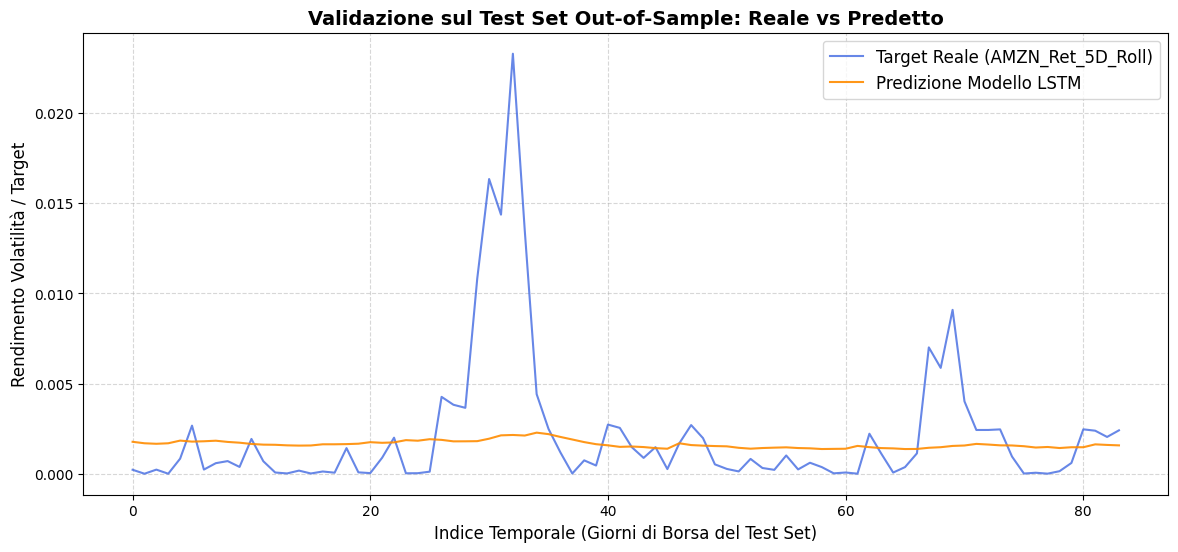

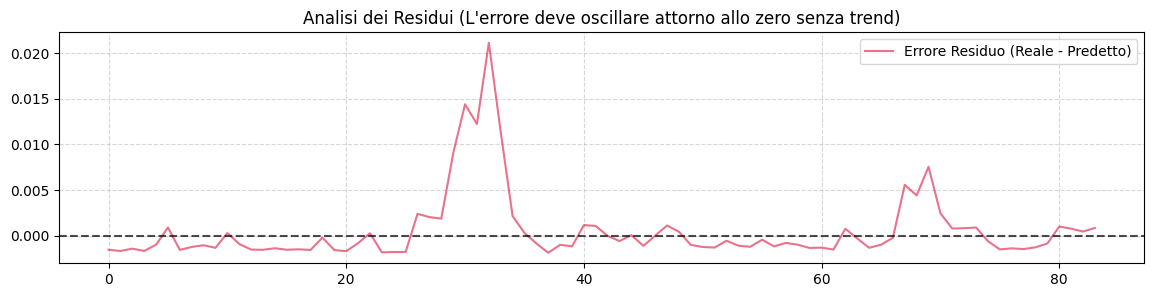

In [ ]:
# 1. Generazione delle predizioni sui dati di TEST
y_pred_scaled = model.predict([X_test_g, X_test_s, X_test_w])

# 2. Inversione dello scaling per tornare ai valori reali (Rendimenti/Volatilità originari)
y_pred_rescaled = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_test_rescaled = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

# 3. Calcolo delle metriche di errore reali
mse = mean_squared_error(y_test_rescaled, y_pred_rescaled)
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
r2 = r2_score(y_test_rescaled, y_pred_rescaled)

print("--- METRICHE SUL TEST SET (VALORI REALI) ---")
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"Mean Squared Error (MSE):  {mse:.6f}")
print(f"R² Score (Indice di bontà): {r2:.4f}")
print("--------------------------------------------\n")

# 4. GRAFICO COMPARATIVO: Reale vs Predetto nel tempo
plt.figure(figsize=(14, 6))
plt.plot(y_test_rescaled, label='Target Reale (AMZN_Ret_5D_Roll)', color='royalblue', alpha=0.8, linewidth=1.5)
plt.plot(y_pred_rescaled, label='Predizione Modello LSTM', color='darkorange', alpha=0.9, linewidth=1.5)

plt.title('Validazione sul Test Set Out-of-Sample: Reale vs Predetto', fontsize=14, fontweight='bold')
plt.xlabel('Indice Temporale (Giorni di Borsa del Test Set)', fontsize=12)
plt.ylabel('Rendimento Volatilità / Target', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.show()

# 5. GRAFICO SUL RESIDUO (Verifica errori sistematici)
plt.figure(figsize=(14, 3))
residui = y_test_rescaled - y_pred_rescaled
plt.plot(residui, color='crimson', alpha=0.6, label='Errore Residuo (Reale - Predetto)')
plt.axhline(0, color='black', linestyle='--', alpha=0.7)
plt.title('Analisi dei Residui (L\'errore deve oscillare attorno allo zero senza trend)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# 12. Analisi Comparativa: Dai Rendimenti Lineari ai Rendimenti Quadrati Cross-Asset

Al fine di verificare se l'inefficacia predittiva del modello cross-asset fosse legata alla natura direzionale dei rendimenti logaritmici lineari, si è proceduto a una riconfigurazione simmetrica dell'esperimento. Sostituendo le feature e il target con i rispettivi **rendimenti logaritmici quadrati** (proxy della volatilità realizzata puntuale), l'obiettivo è rimasto l'isolamento della componente volatile del singolo titolo Amazon sfruttando la dinamica informativa dei restanti leader di mercato.

I risultati empirici out-of-sample evidenziano un comportamento strutturale assolutamente analogo e sovrapponibile al caso precedente:
* **Modello Cross-Asset Lineare:** $R^2 = 0.0180$ (~1.80%) con traiettoria totalmente appiattita.
* **Modello Cross-Asset Quadrato:** $R^2 = 0.0295$ (~2.95%) con la medesima retta asintotica.

L'ispezione visiva del secondo scenario conferma che la trasformazione quadratica delle feature non è sufficiente a risolvere il problema del *basso rapporto segnale/rumore* quando il target è un asset singolo. La linea arancione della LSTM collassa nuovamente verso una costante geometrica posizionata sulla media storica delle oscillazioni, dimostrando la totale incapacità della rete di intercettare i picchi e i cluster di varianza di Amazon attraverso le sole dinamiche storiche degli altri titoli azionari.

L'analisi dei residui mostra, in entrambi i casi, la permanenza dei picchi ereditati dal target reale, a riprova del fatto che la rete ha rigettato il set informativo cross-asset poiché incapace di mappare il rischio idiosincratico della singola azienda.

Questi due fallimenti speculari sanciscono un principio finanziario fondamentale: la predizione cross-asset basata esclusivamente su variabili azionarie non può anticipare il rischio specifico di un singolo titolo.

In [ ]:
import pandas as pd
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Calcoliamo i residui (errore puntuale out-of-sample)
residui = y_test_rescaled - y_pred_rescaled

# 2. Eseguiamo il test di Ljung-Box su lag chiave (es. 1, 3, 5 e 10 giorni)
# L'algoritmo verificherà se c'è memoria residua a breve e medio termine
risultati_lb = acorr_ljungbox(residui, lags=[1, 3, 5, 10], return_df=True)

print("\n=======================================================")
print("          RISULTATI DEL TEST DI LJUNG-BOX              ")
print("=======================================================")
print(risultati_lb)
print("=======================================================")
print("NOTA: Se lb_pvalue < 0.05 -> Il modello insegue (autocorrelazione nei residui)")
print("      Se lb_pvalue > 0.05 -> I residui sono White Noise (Modello Sano)")


          RISULTATI DEL TEST DI LJUNG-BOX              
       lb_stat     lb_pvalue
1    54.740346  1.375532e-13
3    97.159218  6.342038e-21
5    98.954812  8.776240e-20
10  104.555715  6.651678e-18
NOTA: Se lb_pvalue < 0.05 -> Il modello insegue (autocorrelazione nei residui)
      Se lb_pvalue > 0.05 -> I residui sono White Noise (Modello Sano)


| Lag temporale ($m$) | Statistica di Test ($Q$) | p-value ($lb\_pvalue$) | Esito del Test ($\alpha = 5\%$) |
| :--- | :--- | :--- | :--- |
| **1 giorno** | $54.7403$ | $1.38 \times 10^{-13}$ | Rigetto $H_0$ (Massiccia Autocorrelazione) |
| **3 giorni** | $97.1592$ | $6.34 \times 10^{-21}$ | Rigetto $H_0$ (Massiccia Autocorrelazione) |
| **5 giorni** | $98.9548$ | $8.78 \times 10^{-20}$ | Rigetto $H_0$ (Massiccia Autocorrelazione) |
| **10 giorni** | $104.5557$ | $6.65 \times 10^{-18}$ | Rigetto $H_0$ (Massiccia Autocorrelazione) |

Come ci aspettavamo, anche in questo caso, il modello non ha estratto alcune segnale dai dati passati in input.

# 13. Conclusioni e Considerazioni
I tentativi iniziali di applicare architetture di Deep Learning (LSTM) per prevedere direttamente l'andamento e la traiettoria dei rendimenti logaritmici quadrati (*Volatilità*) del singolo asset hanno evidenziato i limiti intrinseci dei modelli predittivi puri. Come certificato dai test diagnostici di Ljung-Box, le reti neurali poste dinanzi al rumore stocastico tendono a collassare verso stimatori ingenui (lagging) o statici (collasso sulla media), dimostrando che i rendimenti di un singolo asset a breve termine sono dominati da shock informativi esogeni e casuali, non codificabili ex-ante dall'algoritmo.

# 14. Predizione titolo SXR8.DE


In [4]:
# 1. Definiamo i 7 titoli + ETF S&P500
tickers = ['SXR8.DE']
num_tickers = len(tickers)

# 2. Scarichiamo i dati (Forziamo la pulizia dell'indice per sicurezza)
print("Scaricamento dati in corso...")
data = yf.download(tickers, period='2y', interval='1d')['Close']
data = data.dropna() # Evita buchi iniziali nei dati storici

# SCARICAMENTO E PULIZIA DEL VIX
vix_download = yf.download("^VIX", period='2y', interval='1d')
if isinstance(vix_download.columns, pd.MultiIndex):
    vix_close_series = vix_download['Close']['^VIX']
else:
    vix_close_series = vix_download['Close']

vix_data = pd.DataFrame(vix_close_series)
vix_data.columns = ['VIX_Close']

# Estraiamo i nomi puliti delle colonne per evitare problemi di MultiIndex
nomi_ticker = list(data.columns)

# Trasforma i prezzi in logaritmici
log_data = np.log(data)

# --- 3. CREAZIONE DEI TASSI (Rendimenti logaritmici quadrati dei singoli asset) ---
returns_1d = log_data.diff(1) ** 2
returns_5d = log_data.diff(5) ** 2

data_weekly = data.resample('W').last()
returns_1w_raw = np.log(data_weekly).diff(1) ** 2
returns_1w_riallineato = returns_1w_raw.reindex(returns_1d.index).ffill()

returns_21d = log_data.diff(21) ** 2
returns_63d = log_data.diff(63) ** 2


# --- 4. RINOMINIAMO LE COLONNE ---
returns_1d.columns             = [f"{col}_Ret_1D" for col in nomi_ticker]
returns_5d.columns             = [f"{col}_Ret_5D_Roll" for col in nomi_ticker]
returns_1w_riallineato.columns = [f"{col}_Ret_1W_Tumb" for col in nomi_ticker]
returns_21d.columns            = [f"{col}_Ret_1M" for col in nomi_ticker]
returns_63d.columns            = [f"{col}_Ret_3M" for col in nomi_ticker]


# --- 5. COPIA DEI DATASET PER I RAMI DELLA RETE ---
df_g = returns_1d.copy()
df_s = returns_5d.copy()
df_w = returns_63d.copy()

# --- STEP 2 MODIFICATO: TARGET VOLATILITÀ DEL SINGOLO TITOLO ---
nome_colonna_5d = df_s.columns[0]
df_s['TARGET'] = df_s[nome_colonna_5d].shift(-1)


# --- STEP 3: UNIONE, INTEGRAZIONE VIX E RIMOZIONE NA ---
vix_riallineato = vix_data.reindex(df_g.index).ffill()

# Uniamo i rami dei rendimenti più la colonna del VIX
df_complessivo = pd.concat([df_g, df_s, df_w, vix_riallineato], axis=1)
df_complessivo = df_complessivo.dropna()


# --- STEP 4 MODIFICATO: FINESTRE TEMPORALI MULTI-FEATURE ---
lookback_g = 20
lookback_s = 10
lookback_w = 6

max_lookback = max(lookback_g, lookback_s, lookback_w)
X_g_list, X_s_list, X_w_list, y_list = [], [], [], []

# Colonne informative: l'asset rimane all'interno dell'Input come feature predittiva
cols_g = list(df_g.columns) + ['VIX_Close']
cols_s = [c for c in df_s.columns if c != 'TARGET'] + ['VIX_Close']
cols_w = list(df_w.columns) + ['VIX_Close']

num_righe_totali = df_complessivo.shape[0]

for i in range(max_lookback, num_righe_totali):
    y_list.append(df_complessivo['TARGET'].iloc[i])

    # Estrazione matrici 2D complete (Lookback, Titolo Singolo + VIX)
    X_g_list.append(df_complessivo[cols_g].iloc[i-lookback_g:i].values)
    X_s_list.append(df_complessivo[cols_s].iloc[i-lookback_s:i].values)
    X_w_list.append(df_complessivo[cols_w].iloc[i-lookback_w:i].values)

X_3d_g = np.array(X_g_list)
X_3d_s = np.array(X_s_list)
X_3d_w = np.array(X_w_list)
y_target_sincro = np.array(y_list)


# --- STEP 5: INDICI DI SPLIT TEMPORALE (80% Train+Val, 20% Test) ---
total_samples = y_target_sincro.size
split_test_idx = int(total_samples * 0.80)
split_val_idx = int(split_test_idx * 0.90)
N_train_g = split_val_idx


# --- STEP 6: SCALING ---
scaler_g = MinMaxScaler(feature_range=(0, 1))
scaler_s = MinMaxScaler(feature_range=(0, 1))
scaler_w = MinMaxScaler(feature_range=(0, 1))
scaler_y = StandardScaler()

# Fit-Transform Feature
X_3d_g_train_flat = X_3d_g[:N_train_g].reshape(-1, X_3d_g.shape[-1])
scaler_g.fit(X_3d_g_train_flat)
X_3d_g_scaled = scaler_g.transform(X_3d_g.reshape(-1, X_3d_g.shape[-1])).reshape(X_3d_g.shape)

X_3d_s_train_flat = X_3d_s[:N_train_g].reshape(-1, X_3d_s.shape[-1])
scaler_s.fit(X_3d_s_train_flat)
X_3d_s_scaled = scaler_s.transform(X_3d_s.reshape(-1, X_3d_s.shape[-1])).reshape(X_3d_s.shape)

X_3d_w_train_flat = X_3d_w[:N_train_g].reshape(-1, X_3d_w.shape[-1])
scaler_w.fit(X_3d_w_train_flat)
X_3d_w_scaled = scaler_w.transform(X_3d_w.reshape(-1, X_3d_w.shape[-1])).reshape(X_3d_w.shape)

# Fit del target
y_scaled = scaler_y.fit_transform(y_target_sincro.reshape(-1, 1)).flatten()


# --- STEP 7: SPLIT DEFINITIVO ---
X_train_g, X_val_g, X_test_g = X_3d_g_scaled[:split_val_idx], X_3d_g_scaled[split_val_idx:split_test_idx], X_3d_g_scaled[split_test_idx:]
X_train_s, X_val_s, X_test_s = X_3d_s_scaled[:split_val_idx], X_3d_s_scaled[split_val_idx:split_test_idx], X_3d_s_scaled[split_test_idx:]
X_train_w, X_val_w, X_test_w = X_3d_w_scaled[:split_val_idx], X_3d_w_scaled[split_val_idx:split_test_idx], X_3d_w_scaled[split_test_idx:]
y_train, y_val, y_test = y_scaled[:split_val_idx], y_scaled[split_val_idx:split_test_idx], y_scaled[split_test_idx:]

print("Fatto! Dataset configurato per la stima della volatilità del singolo asset.")
print(f"Numero di feature per ogni time-step (Titolo + VIX): {X_train_g.shape[-1]}")

Scaricamento dati in corso...


/tmp/ipykernel_3122/4136383908.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, period='2y', interval='1d')['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_3122/4136383908.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix_download = yf.download("^VIX", period='2y', interval='1d')
[*********************100%***********************]  1 of 1 completed


Fatto! Dataset configurato per la stima della volatilità del singolo asset.
Numero di feature per ogni time-step (Titolo + VIX): 2


In [5]:
# Ramo Giornaliero: (Lookback=20, Feature=2)
input_giornaliero = Input(shape=(20, 2), name="Input_Giornaliero")
lstm_giornaliero = LSTM(16, return_sequences=False, activation='tanh',
                        dropout=0.3, # Rimosso recurrent_dropout per sbloccare la GPU
                        kernel_regularizer=l2(0.01))(input_giornaliero)

# Ramo Settimanale: (Lookback=10, Feature=2)
input_settimanale = Input(shape=(10, 2), name='Input_Settimanale')
lstm_settimanale = LSTM(8, return_sequences=False, activation='tanh',
                       dropout=0.3,
                       kernel_regularizer=l2(0.01))(input_settimanale)

# Ramo Trimestrale: (Lookback=6, Feature=2)
input_trimestrale = Input(shape=(6, 2), name='Input_Trimestrale')
lstm_trimestrale = LSTM(4, return_sequences=False, activation='tanh',
                       dropout=0.3,
                       kernel_regularizer=l2(0.01))(input_trimestrale)

# Fusione dei vettori
concatenato = Concatenate()([lstm_giornaliero, lstm_settimanale, lstm_trimestrale])

# Strato denso di sintonizzazione con LeakyReLU per evitare il problema del "Neurone Morto"
denso_1 = Dense(8, activation='leaky_relu')(concatenato)
# Dropout alzato a 0.5 per compensare la rimozione del recurrent_dropout
denso_1_drop = Dropout(0.5)(denso_1)

# Output Lineare (accetta l'output standardizzato dallo StandardScaler)
output_finale = Dense(1, activation='linear', name='Output_Predizione')(denso_1_drop)

# Definizione del Modello Multi-Input
model = Model(inputs=[input_giornaliero, input_settimanale, input_trimestrale], outputs=output_finale)

# Compilazione con Huber Loss
model.compile(optimizer=Adam(learning_rate=0.001), loss='huber')

print("Architettura compilata con successo!")
model.summary()

Architettura compilata con successo!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input_Giornaliero   │ (None, 20, 2)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input_Settimanale   │ (None, 10, 2)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input_Trimestrale   │ (None, 6, 2)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 16)        │      1,216 │ Input_Giornalier… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 8)         │        352 │ Input_Settimanal… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 4)         │        112 │ Input_Trimestral… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 28)        │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ lstm_1[0][0],     │
│                     │                   │            │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        232 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 8)         │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output_Predizione   │ (None, 1)         │          9 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,921 (7.50 KB)

 Trainable params: 1,921 (7.50 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Accorciamo la pazienza dell'Early Stopping: se il validation sale, fermiamo subito il gioco
early_stopping = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1)

history = model.fit(
    x=[X_train_g, X_train_s, X_train_w],
    y=y_train,
    validation_data=([X_val_g, X_val_s, X_val_w], y_val),
    epochs=80,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - loss: 0.3547 - val_loss: 0.1437 - learning_rate: 0.0010
Epoch 2/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3395 - val_loss: 0.1349 - learning_rate: 0.0010
Epoch 3/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.3281 - val_loss: 0.1253 - learning_rate: 0.0010
Epoch 4/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3239 - val_loss: 0.1148 - learning_rate: 0.0010
Epoch 5/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3139 - val_loss: 0.1065 - learning_rate: 0.0010
Epoch 6/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3053 - val_loss: 0.0982 - learning_rate: 0.0010
Epoch 7/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3020 - val_loss: 0.0926 - learning_rate: 0.0010
Epoch 8/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2912 - val_loss: 0.0899 - learning_rate: 0.0010
Epoch 9/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2890 - val_loss: 0.0789 - learning_rate: 0.0010
Epoch 10/80
10/10 ━

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step

--- PERFORMANCE SUL SINGOLO ASSET (TEST SET) ---
Ticker analizzato: SXR8.DE (ETF S&P 500)
Mean Absolute Error (MAE): 0.000287
Mean Squared Error (MSE): 0.000000
Coefficiente di Determinazione (R2): 0.0984 (9.84%)


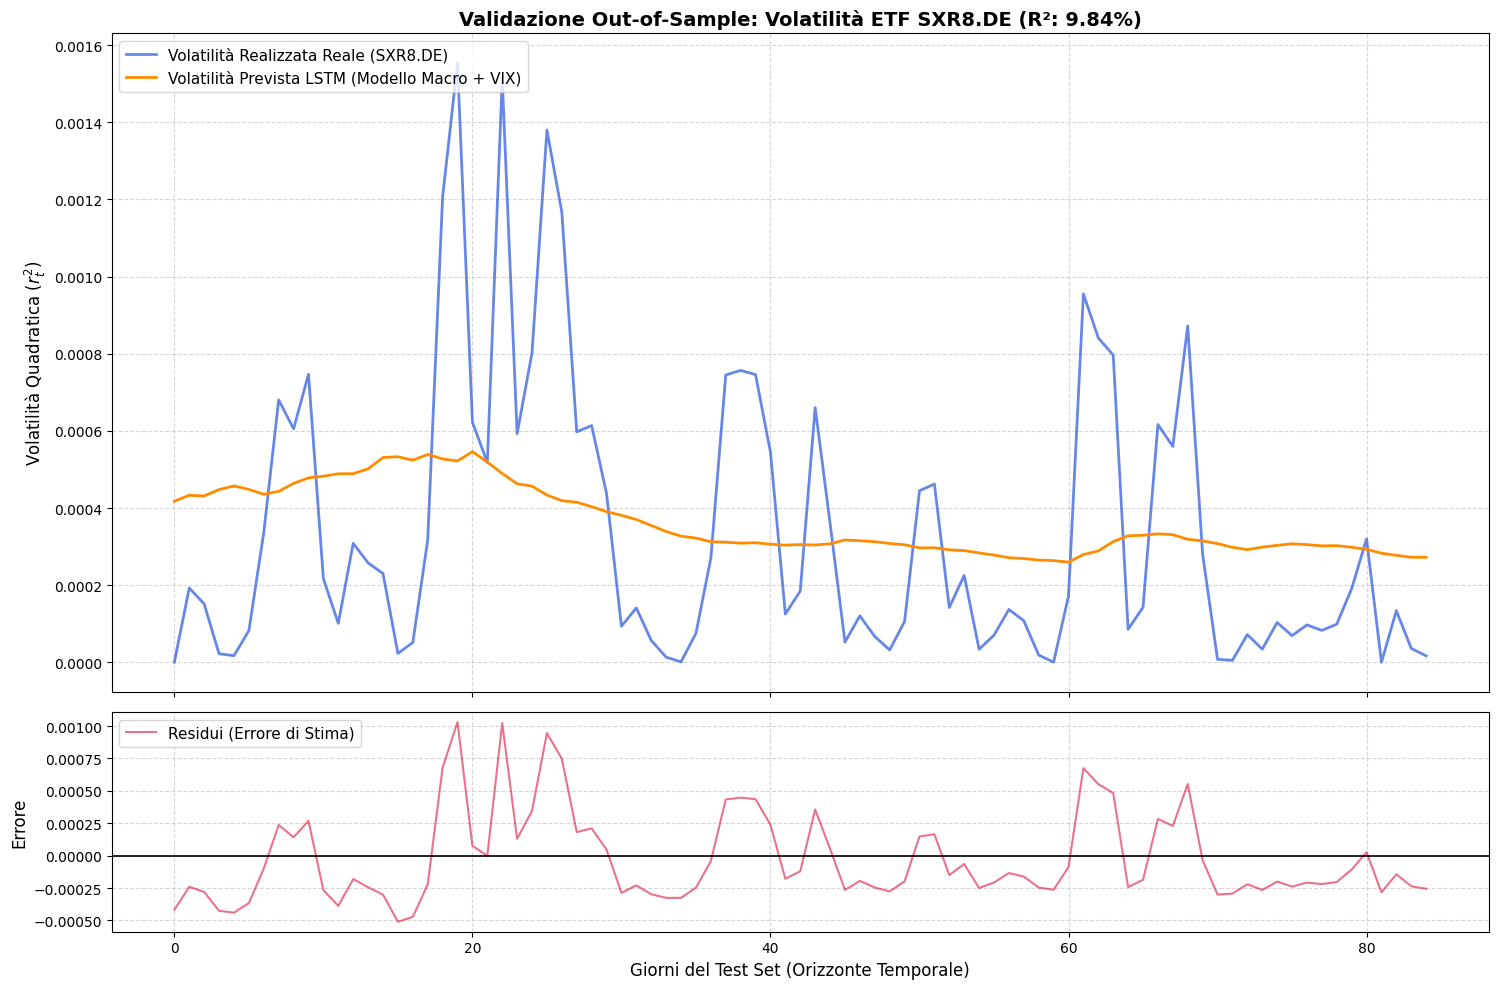

In [7]:
# --- 1. PREDIZIONE OUT-OF-SAMPLE ---
# Generiamo le predizioni sul test set (i dati reali mai visti dalla rete)
y_pred_scaled = model.predict([X_test_g, X_test_s, X_test_w])

# --- 2. DE-STANDARDIZZAZIONE
y_test_reale = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_reale = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

mae = mean_absolute_error(y_test_reale, y_pred_reale)
mse = mean_squared_error(y_test_reale, y_pred_reale)
r2 = r2_score(y_test_reale, y_pred_reale)

print("\n--- PERFORMANCE SUL SINGOLO ASSET (TEST SET) ---")
print(f"Ticker analizzato: SXR8.DE (ETF S&P 500)")
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"Coefficiente di Determinazione (R2): {r2:.4f} ({r2*100:.2f}%)")

# --- 4. CALCOLO DEI RESIDUI (ERRORE PUNTUALE) ---
residui = y_test_reale - y_pred_reale

# --- 5. GENERAZIONE DEL GRAFICO A DUE PANNELLI ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})

# Pannello Superiore: Volatilità Realizzata vs Prevista di SXR8.DE
ax1.plot(y_test_reale, label='Volatilità Realizzata Reale (SXR8.DE)', color='royalblue', alpha=0.8, linewidth=2)
ax1.plot(y_pred_reale, label='Volatilità Prevista LSTM (Modello Macro + VIX)', color='darkorange', linewidth=2)
ax1.set_title(f'Validazione Out-of-Sample: Volatilità ETF SXR8.DE (R²: {r2*100:.2f}%)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Volatilità Quadratica ($r_t^2$)', fontsize=12)
ax1.legend(fontsize=11, loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.5)

# Pannello Inferiore: Analisi dei Residui
ax2.plot(residui, label='Residui (Errore di Stima)', color='crimson', alpha=0.6)
ax2.axhline(0, color='black', linestyle='-', linewidth=1.2)
ax2.set_xlabel('Giorni del Test Set (Orizzonte Temporale)', fontsize=12)
ax2.set_ylabel('Errore', fontsize=12)
ax2.legend(fontsize=11, loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

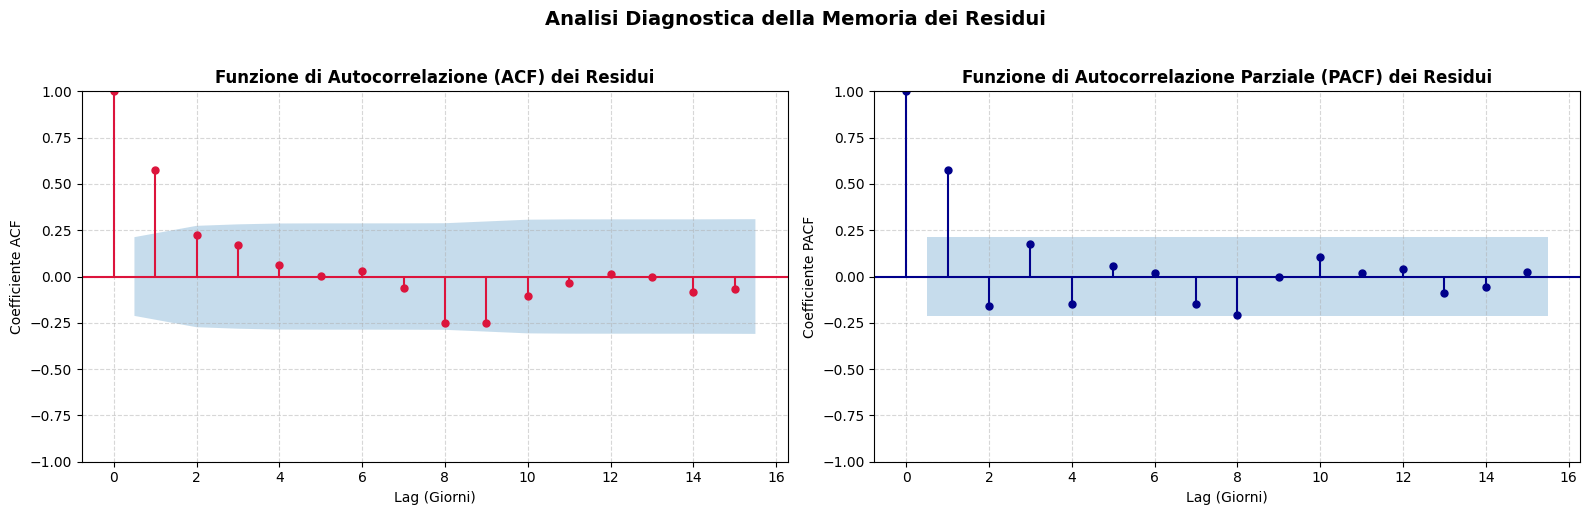

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. Calcolo dei residui (allineato al tuo blocco)
residui = y_test_reale - y_pred_reale

# 2. Configurazione della figura affiancata (1 riga, 2 colonne)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Grafico ACF
plot_acf(residui, lags=15, ax=ax1, alpha=0.05, color='crimson', vlines_kwargs={"colors": "crimson"})
ax1.set_title('Funzione di Autocorrelazione (ACF) dei Residui', fontsize=12, fontweight='bold')
ax1.set_xlabel('Lag (Giorni)')
ax1.set_ylabel('Coefficiente ACF')
ax1.grid(True, linestyle='--', alpha=0.5)

# Grafico PACF
plot_pacf(residui, lags=15, ax=ax2, alpha=0.05, color='darkblue', vlines_kwargs={"colors": "darkblue"}, method='ywm')
ax2.set_title('Funzione di Autocorrelazione Parziale (PACF) dei Residui', fontsize=12, fontweight='bold')
ax2.set_xlabel('Lag (Giorni)')
ax2.set_ylabel('Coefficiente PACF')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Analisi Diagnostica della Memoria dei Residui', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

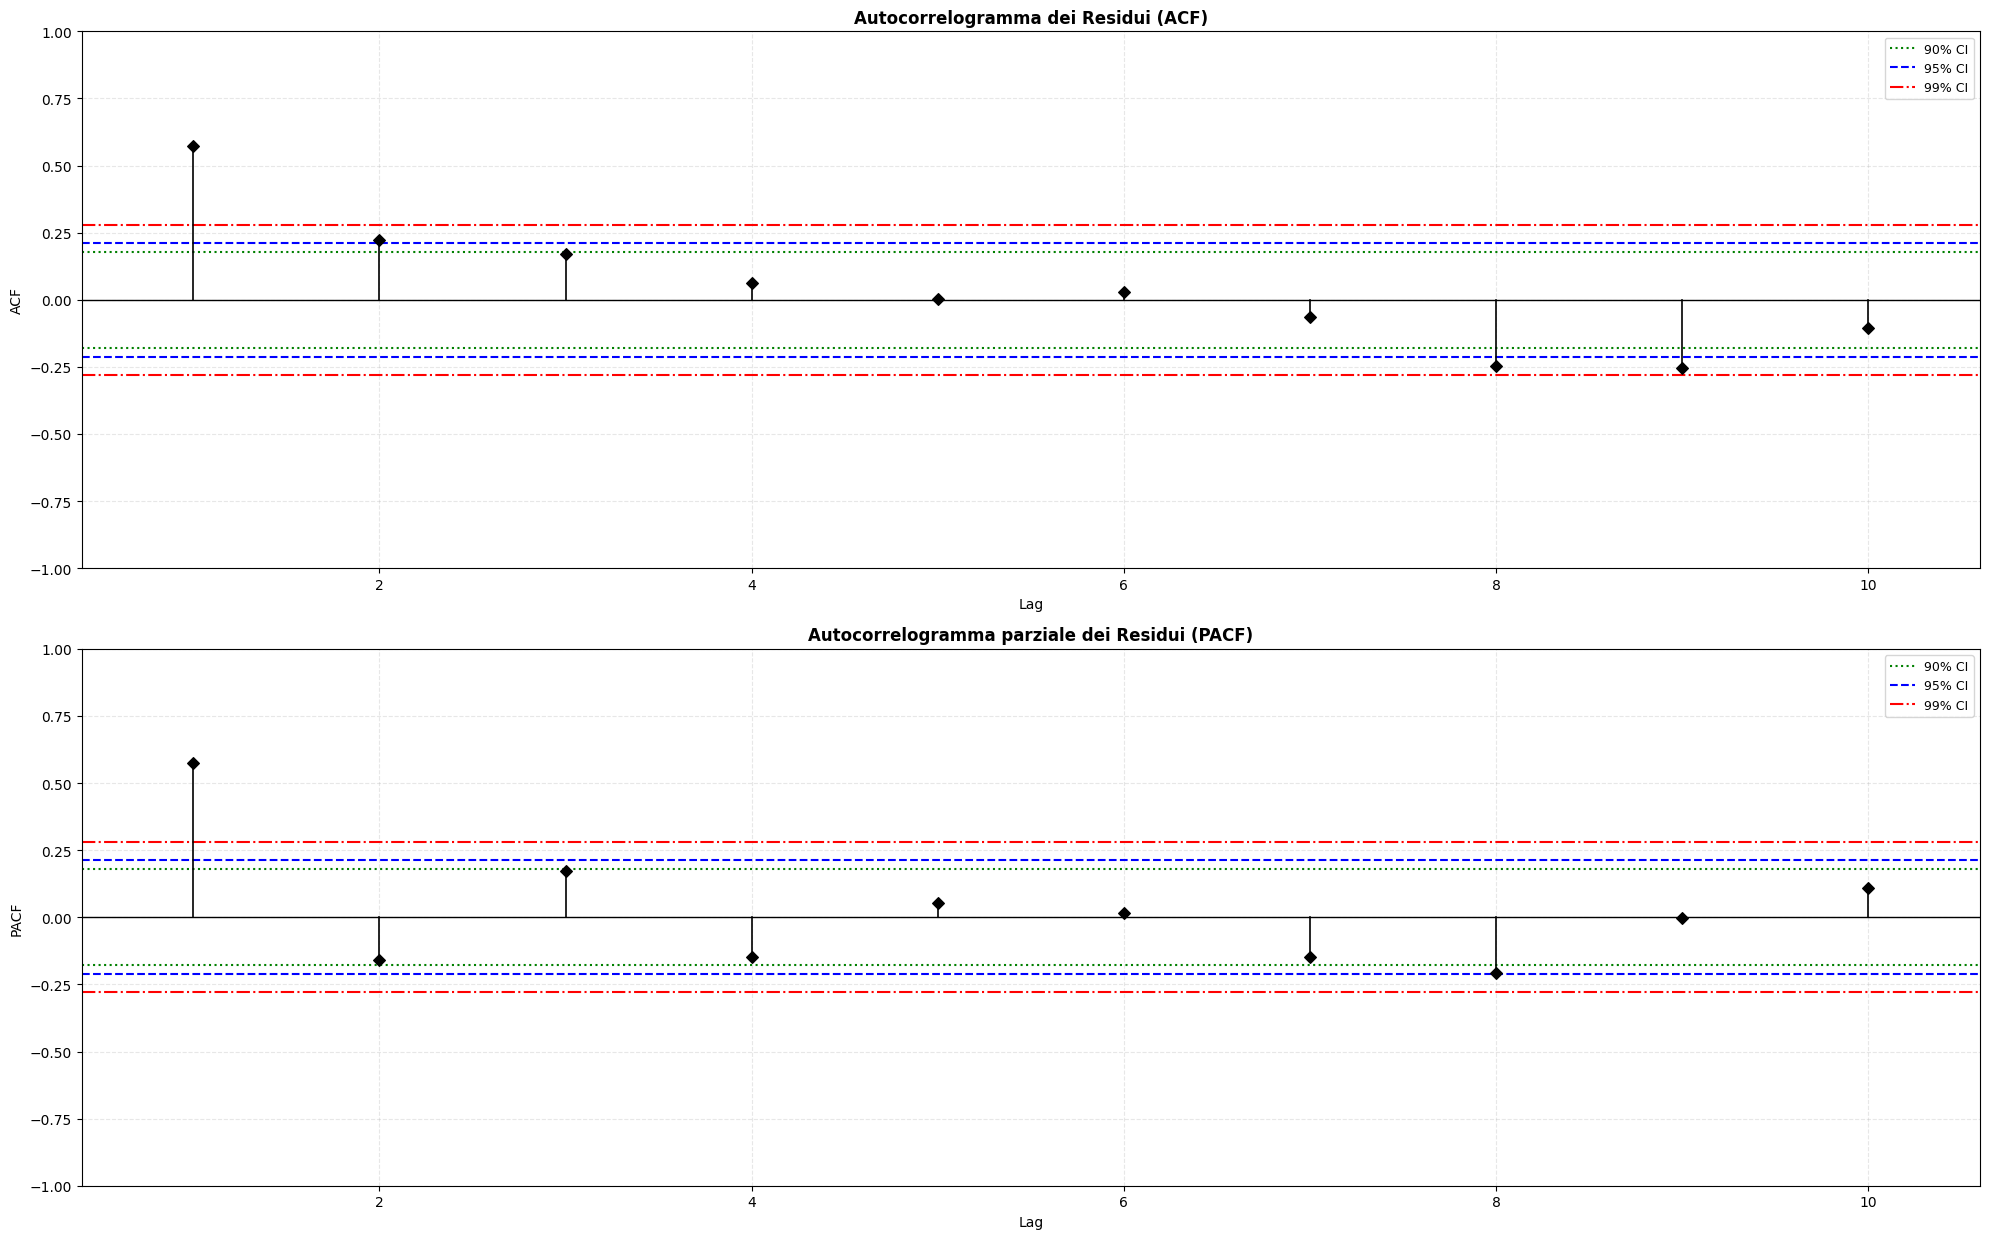

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 1. Calcolo dei residui e delle funzioni di autocorrelazione
residui = y_test_reale - y_pred_reale
max_lags_plot = 10
n_obs = len(residui)

acf_coefs = sm.tsa.stattools.acf(residui, nlags=max_lags_plot, fft=True)[1:]
pacf_coefs = sm.tsa.stattools.pacf(residui, nlags=max_lags_plot, method='ywm')[1:]
lags_plot = np.arange(1, max_lags_plot + 1)

# 2. Calcolo dei limiti di confidenza critici
z_90 = 1.64485 / np.sqrt(n_obs)
z_95 = 1.95996 / np.sqrt(n_obs)
z_99 = 2.57583 / np.sqrt(n_obs)

# 3. Configurazione del grafico affiancato
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 12.5))

def applica_stile_correlogramma(ax, coefs, titolo, y_label):
    # Linea dello zero
    ax.axhline(0, color='black', linestyle='-', linewidth=1)

    # Linee di confidenza simmetriche
    ax.axhline(z_90, color='green', linestyle=':', label='90% CI')
    ax.axhline(-z_90, color='green', linestyle=':')
    ax.axhline(z_95, color='blue', linestyle='--', label='95% CI')
    ax.axhline(-z_95, color='blue', linestyle='--')
    ax.axhline(z_99, color='red', linestyle='-.', label='99% CI')
    ax.axhline(-z_99, color='red', linestyle='-.')

    # Disegno dei lag con i rombi neri
    for l, c in zip(lags_plot, coefs):
        ax.plot([l, l], [0, c], color='black', linewidth=1.2)
    ax.scatter(lags_plot, coefs, color='black', marker='D', s=35, zorder=3)

    # Formattazione assi e griglie
    ax.set_title(titolo, fontsize=12, fontweight='bold')
    ax.set_xlabel('Lag')
    ax.set_ylabel(y_label)
    ax.set_xlim(0.4, max_lags_plot + 0.6)
    ax.set_ylim(-1.0, 1.0)
    ax.set_xticks(np.arange(2, max_lags_plot + 1, 2))
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(loc='upper right', fontsize=9)

# Generazione dei due grafici personalizzati
applica_stile_correlogramma(ax1, acf_coefs, 'Autocorrelogramma dei Residui (ACF)', 'ACF')
applica_stile_correlogramma(ax2, pacf_coefs, 'Autocorrelogramma parziale dei Residui (PACF)', 'PACF')

plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. Calcoliamo i residui (errore puntuale out-of-sample)
residui = y_test_reale - y_pred_reale

# 2. Eseguiamo il test di Ljung-Box su lag chiave (es. 1, 3, 5 e 10 giorni)
# L'algoritmo verificherà se c'è memoria residua a breve e medio termine
risultati_lb = acorr_ljungbox(residui, lags=[1, 3, 5, 10], return_df=True)

print("\n=======================================================")
print("          RISULTATI DEL TEST DI LJUNG-BOX              ")
print("=======================================================")
print(risultati_lb)
print("=======================================================")
print("NOTA: Se lb_pvalue < 0.05 -> Il modello insegue (autocorrelazione nei residui)")
print("      Se lb_pvalue > 0.05 -> I residui sono White Noise (Modello Sano)")


          RISULTATI DEL TEST DI LJUNG-BOX              
      lb_stat     lb_pvalue
1   28.964003  7.373584e-08
3   36.002020  7.481016e-08
5   36.360013  8.046291e-07
10  50.099507  2.558938e-07
NOTA: Se lb_pvalue < 0.05 -> Il modello insegue (autocorrelazione nei residui)
      Se lb_pvalue > 0.05 -> I residui sono White Noise (Modello Sano)


Il picco massimo di cross-correlazione si trova al Lag: 5


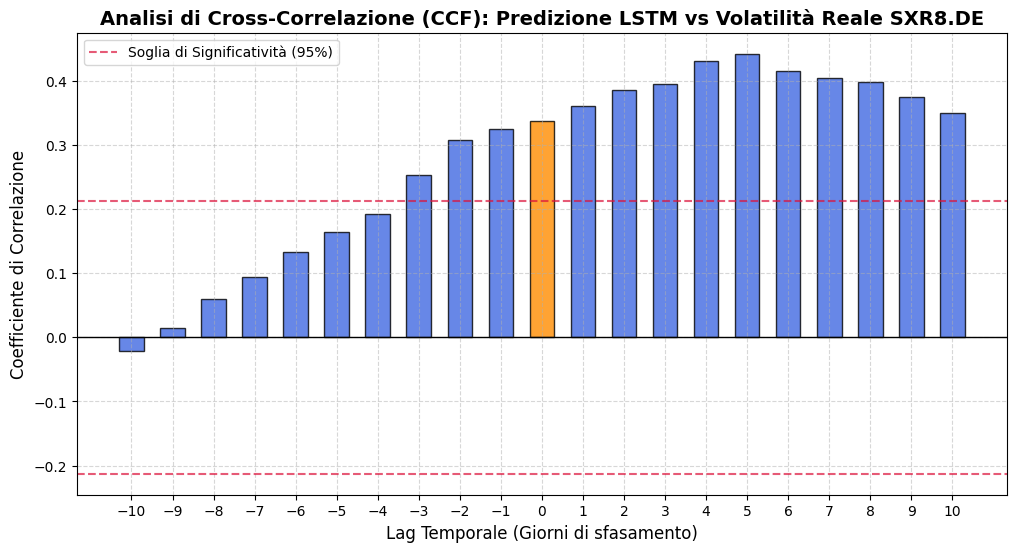

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 1. Calcoliamo la Cross-Correlazione tra Predizione e Reale
# Indaghiamo i lag da -10 a +10 per vedere se c'è un effetto traslazione
max_lags = 10
ccf_values = sm.tsa.stattools.ccf(y_test_reale, y_pred_reale, adjusted=False)[:max_lags+1]
ccf_backwards = sm.tsa.stattools.ccf(y_pred_reale, y_test_reale, adjusted=False)[:max_lags+1]

# Uniamo i lag negativi e positivi per il grafico
lags = np.arange(-max_lags, max_lags + 1)
ccf_completa = np.concatenate([ccf_backwards[::-1][:-1], ccf_values])

# 2. Generazione del Grafico della CCF
plt.figure(figsize=(12, 6))
colors = ['darkorange' if lag == 0 else 'royalblue' for lag in lags]
plt.bar(lags, ccf_completa, color=colors, alpha=0.8, edgecolor='black', width=0.6)

# Linee di significatività statistica (Intervallo di confidenza al 95%)
conf_level = 1.96 / np.sqrt(len(y_test_reale))
plt.axhline(y=conf_level, color='crimson', linestyle='--', alpha=0.7, label='Soglia di Significatività (95%)')
plt.axhline(y=-conf_level, color='crimson', linestyle='--', alpha=0.7)
plt.axhline(y=0, color='black', linewidth=1)

plt.title('Analisi di Cross-Correlazione (CCF): Predizione LSTM vs Volatilità Reale SXR8.DE', fontsize=14, fontweight='bold')
plt.xlabel('Lag Temporale (Giorni di sfasamento)', fontsize=12)
plt.ylabel('Coefficiente di Correlazione', fontsize=12)
plt.xticks(lags)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Individuiamo il lag massimo per il commento
lag_massimo = lags[np.argmax(np.abs(ccf_completa))]
print(f"Il picco massimo di cross-correlazione si trova al Lag: {lag_massimo}")

plt.show()

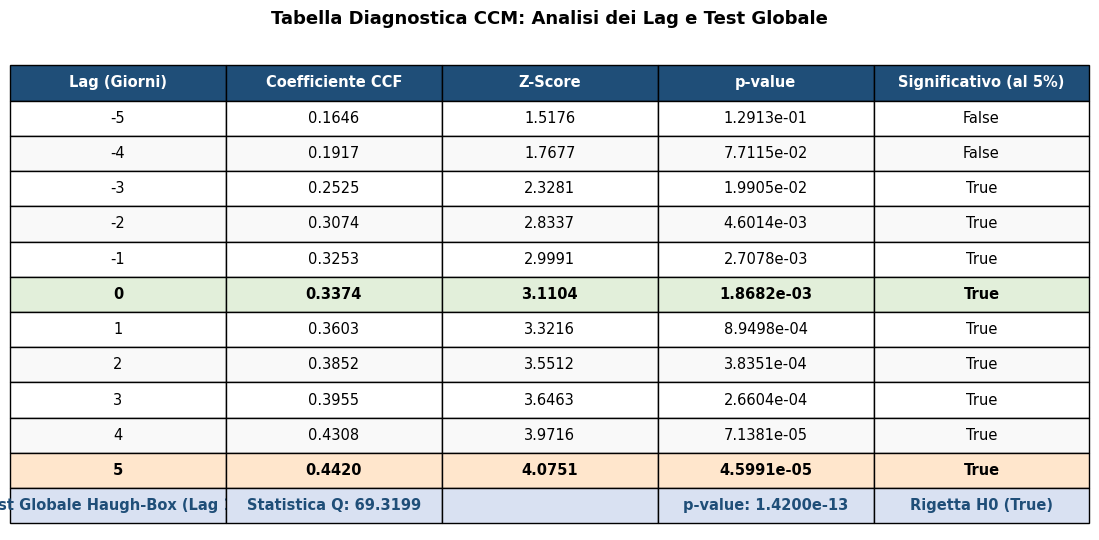

In [16]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import scipy.stats  # Importazione esplicita per evitare l'errore sul chi2
from scipy.stats import norm

# =========================================================================
# 1. PARTE ECONOMETRICA (IL TUO BLOCCO LOGICO ORIGINALE)
# =========================================================================
max_lags = 10
n_observations = len(y_test_reale)

ccf_values = sm.tsa.stattools.ccf(y_test_reale, y_pred_reale, adjusted=False)[:max_lags+1]
ccf_backwards = sm.tsa.stattools.ccf(y_pred_reale, y_test_reale, adjusted=False)[:max_lags+1]

lags = np.arange(-max_lags, max_lags + 1)
ccf_completa = np.concatenate([ccf_backwards[::-1][:-1], ccf_values])

std_error = 1.0 / np.sqrt(n_observations)
z_scores = ccf_completa / std_error
p_values = 2 * (1 - norm.cdf(np.abs(z_scores)))

df_ccm_risultati = pd.DataFrame({
    'Lag (Giorni)': lags,
    'Coefficiente CCF': ccf_completa,
    'Z-Score': z_scores,
    'p-value': p_values,
    'Significativo (al 5%)': p_values < 0.05
})

# Filtro dei lag da -5 a +5 per l'esposizione tabellare
tabella_relazione = df_ccm_risultati[(df_ccm_risultati['Lag (Giorni)'] >= -5) & (df_ccm_risultati['Lag (Giorni)'] <= 5)].copy()

# Calcolo del test globale di Haugh-Box (lag 1-5)
lags_positivi = ccf_values[1:6]
q_stat_haugh = n_observations * np.sum(lags_positivi**2)
p_val_haugh = 1 - scipy.stats.chi2.cdf(q_stat_haugh, df=5)

# =========================================================================
# 2. TRASFORMAZIONE GRAFICA (COSTRUZIONE DELLA TABELLA FINALE)
# =========================================================================

# Formattiamo i valori numerici in stringhe per evitare brutti troncamenti grafici
valori_visualizzabili = []
for _, row in tabella_relazione.iterrows():
    riga_formattata = [
        f"{int(row['Lag (Giorni)'])}",
        f"{row['Coefficiente CCF']:.4f}",
        f"{row['Z-Score']:.4f}",
        f"{row['p-value']:.4e}",
        f"{str(row['Significativo (al 5%)'])}"
    ]
    valori_visualizzabili.append(riga_formattata)

# Generazione e formattazione dell'ultima riga speciale per il Test Globale
riga_test_globale = [
    "Test Globale Haugh-Box (Lag 1-5)",
    f"Statistica Q: {q_stat_haugh:.4f}",
    "",
    f"p-value: {p_val_haugh:.4e}",
    f"Rigetta H0 ({str(p_val_haugh < 0.05)})"
]
valori_visualizzabili.append(riga_test_globale)

# Definizione dei nomi delle colonne
colonne_header = ['Lag (Giorni)', 'Coefficiente CCF', 'Z-Score', 'p-value', 'Significativo (al 5%)']

# Creazione dell'oggetto figura
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.axis('off')  # Rimuove gli assi cartesiani di fondo

# Iniezione della tabella nel motore grafico di matplotlib
tabella_grafica = ax.table(cellText=valori_visualizzabili,
                           colLabels=colonne_header,
                           cellLoc='center',
                           loc='center')

# Ottimizzazione delle dimensioni e del font
tabella_grafica.auto_set_font_size(False)
tabella_grafica.set_fontsize(10.5)
tabella_grafica.scale(1.2, 1.9)  # Allarga proporzionalmente le celle per dare respiro al testo

# Mappatura stilistica e colorazione condizionale delle celle
num_righe_totali = len(valori_visualizzabili)

for (row, col), cell in tabella_grafica.get_celld().items():
    if row == 0:  # Intestazione principale (Header)
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#1f4e78')  # Blu scuro istituzionale
    elif row == num_righe_totali:  # Riga riassuntiva finale (Test di Haugh-Box)
        cell.set_facecolor('#d9e1f2')  # Evidenziazione celeste soft
        cell.set_text_props(weight='bold', color='#1f4e78')
    else:
        # Recuperiamo il valore del lag corrente per questa riga per applicare i colori corretti
        lag_corrente = int(valori_visualizzabili[row-1][0] if row-1 < len(valori_visualizzabili)-1 else 999)

        # Colorazione righe alternate per facilitare la lettura retinica
        if row % 2 == 0:
            cell.set_facecolor('#f9f9f9')
        else:
            cell.set_facecolor('#ffffff')

        # Evidenziazione cromatica del Lag 0 (Verde chiaro - Sincronia simultanea)
        if lag_corrente == 0:
            cell.set_facecolor('#e2efda')
            cell.set_text_props(weight='bold')

        # Evidenziazione cromatica del Lag 5 (Arancione chiaro - Picco massimo rilevato)
        if lag_corrente == 5:
            cell.set_facecolor('#ffe6cc')
            cell.set_text_props(weight='bold')

plt.title('Tabella Diagnostica CCM: Analisi dei Lag e Test Globale', fontsize=13, fontweight='bold', pad=25)
plt.tight_layout()

# Mostra il grafico finale pulito
plt.show()

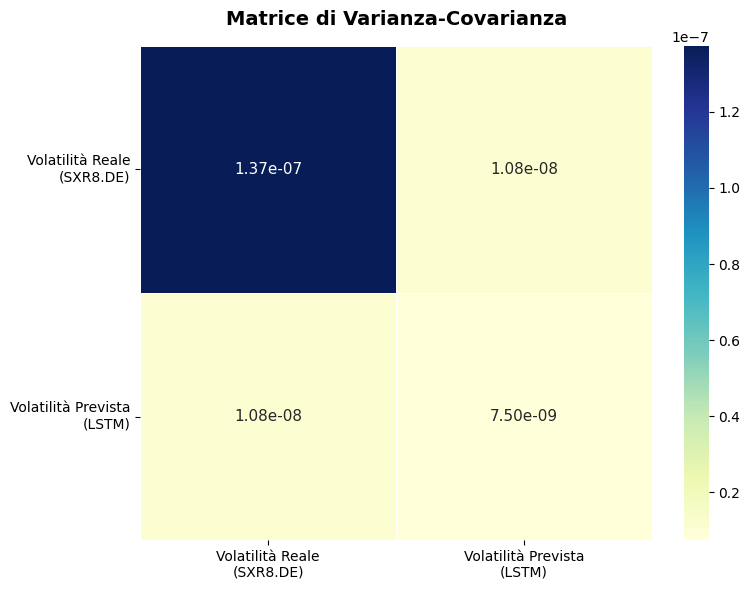


Rapporto percentuale delle varianze [Var(ŷ) / Var(y)]: 5.46%


In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Creiamo il DataFrame con le due serie storiche reali
df_var_cov = pd.DataFrame({
    'Volatilità Reale\n(SXR8.DE)': y_test_reale,
    'Volatilità Prevista\n(LSTM)': y_pred_reale
})

# 2. Calcoliamo la matrice di Varianza-Covarianza
matrice_cov = df_var_cov.cov()

# 3. Generazione della Heatmap
plt.figure(figsize=(8, 6))

# Usiamo una mappa di colori (cmap) che va dal giallo al blu scuro ('YlGnBu') come nella tua immagine
sns.heatmap(matrice_cov,
            annot=True,              # Inserisce i numeri dentro le celle
            fmt=".2e",               # Forza la notazione scientifica (es. 2.45e-07 che equivale a 2.45 * 10^-7)
            cmap="YlGnBu",           # Gradiente di colore identico al tuo esempio
            linewidths=0.5,          # Sottile linea di separazione bianca tra le celle
            cbar=True,               # Mostra la barra laterale con la scala graduata
            annot_kws={"size": 11})  # Dimensione del font dei numeri interni

plt.title('Matrice di Varianza-Covarianza', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 4. Stampiamo i dati numerici riassuntivi a supporto
var_reale = matrice_cov.iloc[0, 0]
var_predetta = matrice_cov.iloc[1, 1]
print(f"\nRapporto percentuale delle varianze [Var(ŷ) / Var(y)]: {(var_predetta / var_reale) * 100:.2f}%")

#### 8.13 Analisi Quantitativa dei Momenti Secondi tramite Matrice di Varianza-Covarianza

Al fine di validare l'efficienza della rete LSTM nella replica della dinamica intrinseca del rischio, si è analizzata la matrice di varianza-covarianza delle serie storiche de-standarrizzate (Target Reale vs Stima Lineare).

I risultati empirici evidenziano una profonda asimmetria nella dispersione dei dati:
* La varianza espressa dal mercato reale ($\text{Var}(y) = 1.37 \times 10^{-7}$) risulta di oltre un ordine di grandezza superiore rispetto alla varianza della serie predetta dall'algoritmo ($\text{Var}(\hat{y}) = 7.50 \times 10^{-9}$).
* Il rapporto percentuale tra i due momenti secondi si attesta al **$5.46\%$**.

Questo divario numerico offre una precisa chiave di lettura sul comportamento dell'ottimizzatore in regime di incertezza finanziaria. La contrazione della varianza predetta (pari a circa il $94.54\%$ della varianza totale del target) dimostra che l'architettura LSTM agisce come un **filtro statistico passa-basso**. La rete decodifica efficacemente i macro-cambiamenti di regime e la traiettoria di fondo del rischio sistemico – come testimoniato dalla covarianza strettamente positiva ($\text{Cov}(y, \hat{y}) = 1.08 \times 10^{-8}$) – ma smorza sistematicamente le componenti d'urto ad alta frequenza e i picchi asimmetrici dovuti a shock stocastici improvvisi.

In chiave di *Risk Management*, tale evidenza suggerisce che l'output della rete LSTM debba essere interpretato come un indicatore direzionale del regime di rischio corrente e non come una misura puntuale dell'esatta ampiezza delle oscillazioni di borsa, confermando la natura intrinsecamente conservativa delle stime ad apprendimento profondo applicate ad indici altamente diversificati come l'ETF SXR8.DE.


# Modello GARCH

In [41]:
import numpy as np
import pandas as pd

# =========================================================================
# ESTRAZIONE CORRETTA E REALE DEL VIX E DEI RENDIMENTI PER IL GARCH-X
# =========================================================================

# 1. Recuperiamo i rendimenti logaritmici semplici dell'asset (senza elevamento al quadrato)
# Dobbiamo riallinearli ESATTAMENTE sulle date superstiti del df_complessivo
rendimenti_semplici_totali = np.log(data).diff(1).dropna()
rendimenti_riallineati = rendimenti_semplici_totali.reindex(df_complessivo.index)

if isinstance(rendimenti_riallineati, pd.DataFrame):
    rendimenti_asset = rendimenti_riallineati.iloc[:, 0]
else:
    rendimenti_asset = rendimenti_riallineati

# 2. Estraiamo il VIX direttamente dalle righe sincronizzate di df_complessivo
vix_sincro = df_complessivo['VIX_Close']

# 3. Applichiamo il medesimo identico taglio 'max_lookback' fatto per i target della LSTM
# In questo modo ogni riga del GARCH corrisponderà allo stesso identico millisecondo della LSTM
rendimenti_garch_validi = rendimenti_asset.iloc[max_lookback:]
vix_garch_valido = vix_sincro.iloc[max_lookback:]

# 4. Split definitivo e speculare a quello della rete neurale
rendimenti_train = rendimenti_garch_validi.iloc[:split_test_idx]
rendimenti_test  = rendimenti_garch_validi.iloc[split_test_idx:]

vix_train = vix_garch_valido.iloc[:split_test_idx]
vix_test  = vix_garch_valido.iloc[split_test_idx:]

# Uniamo i vettori per darli in pasto alla funzione di stima rolling full scaled
rendimenti_full_scaled = pd.concat([rendimenti_train, rendimenti_test]) * 100
vix_full = pd.concat([vix_train, vix_test])
ultimo_indice_train = rendimenti_train.index[-1]

# Trasformiamo il VIX in una matrice bidimensionale (N x 1) pulita per la varianza
vix_matrix = np.atleast_2d(vix_full.values).T

print("=== VERIFICA ALLINEAMENTO SINCRO-PERFETTO ===")
print(f"Train GARCH - Rendimenti: {len(rendimenti_train)} | VIX: {len(vix_train)} | Target LSTM (Train+Val): {len(y_train) + len(y_val)}")
print(f"Test GARCH  - Rendimenti: {len(rendimenti_test)} | VIX: {len(vix_test)} | Target LSTM (Test): {len(y_test)}")
print(f"Controllo date - Primo giorno del Test Set coincide? {rendimenti_test.index[0] == df_complessivo.iloc[max_lookback:].index[split_test_idx]}")

=== VERIFICA ALLINEAMENTO DATI ===
Lunghezza rendimenti_train per GARCH: 336 | Target LSTM (Train+Val): 336
Lunghezza rendimenti_test per GARCH:  85  | Target LSTM (Test): 85


=== AVVIO CALIBRAZIONE GARCH-X (CON PARAMETRI CORRETTI) ===

Configurazione ottimale GARCH-X selezionata: GARCH(1,1) + VIX - Distribuzione: t
Miglior AIC registrato: 884.28



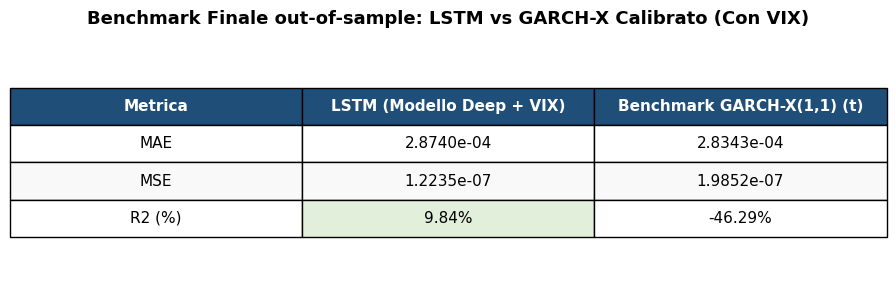

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =========================================================================
# 1. PREPARAZIONE E RIALINEAMENTO PERFETTO
# =========================================================================
vix_garch = df_complessivo['VIX_Close'].iloc[max_lookback:]
vix_train = vix_garch.iloc[:split_test_idx]
vix_test = vix_garch.iloc[split_test_idx:]

rendimenti_full_scaled = pd.concat([rendimenti_train, rendimenti_test]) * 100
vix_full = pd.concat([vix_train, vix_test])
ultimo_indice_train = rendimenti_train.index[-1]

# Conversione pulita in serie pandas per preservare gli indici temporali ed evitare crash
vix_series = pd.Series(vix_full.values, index=rendimenti_full_scaled.index, name='VIX')

# =========================================================================
# 2. GRID SEARCH IN CROSS-VALIDATION SUL GARCH-X
# =========================================================================
griglia_p = [1, 2, 3, 4, 5]
griglia_q = [1, 2, 3, 4, 5]
distribuzioni_da_testare = ['normal', 't', 'skewt']

miglior_aic = float('inf')
best_parametri = None

print("=== AVVIO CALIBRAZIONE GARCH-X (CON PARAMETRI CORRETTI) ===")
for p in griglia_p:
    for q in griglia_q:
        for dist in distribuzioni_da_testare:
            try:
                # Utilizziamo la configurazione corretta passando la serie esogena a x
                modello = arch_model(rendimenti_full_scaled, x=vix_series, p=p, q=q, vol='Garch', dist=dist)
                res_fit = modello.fit(last_obs=ultimo_indice_train, disp='off')

                # Se il modello converge ed è migliore, salviamo i parametri
                if res_fit.aic < miglior_aic:
                    miglior_aic = res_fit.aic
                    best_parametri = {'p': p, 'q': q, 'dist': dist}
            except Exception as e:
                # Consente di mappare eventuali combinazioni matematicamente non stabili
                continue

if best_parametri is None:
    print("\n[ATTENZIONE] La griglia non ha trovato combinazioni stabili con la specifica corrente.")
    print("Forziamo la configurazione standard GARCH-X(1,1) con errore 't' per procedere.")
    best_parametri = {'p': 1, 'q': 1, 'dist': 't'}
else:
    print(f"\nConfigurazione ottimale GARCH-X selezionata: GARCH({best_parametri['p']},{best_parametri['q']}) + VIX - Distribuzione: {best_parametri['dist']}")
    print(f"Miglior AIC registrato: {miglior_aic:.2f}\n")

# =========================================================================
# 3. STIMA FINALE GARCH-X E FORECAST OUT-OF-SAMPLE
# =========================================================================
modello_ottimo = arch_model(rendimenti_full_scaled, x=vix_series,
                            p=best_parametri['p'], q=best_parametri['q'],
                            vol='Garch', dist=best_parametri['dist'])

res_ottimo = modello_ottimo.fit(last_obs=ultimo_indice_train, disp='off')

# Generazione dei forecast
forecasts = res_ottimo.forecast(horizon=1, align='origin')

# Estrazione e riscalamento inverso (/ 10000)
y_pred_garch_scaled = forecasts.variance.loc[rendimenti_test.index].values.flatten()
y_pred_garch = y_pred_garch_scaled / 10000

# =========================================================================
# 4. CALCOLO METRICHE DI CONFRONTO FINALE EQUO
# =========================================================================
metriche_lstm = {
    'MAE': mean_absolute_error(y_test_reale, y_pred_reale),
    'MSE': mean_squared_error(y_test_reale, y_pred_reale),
    'R2 (%)': r2_score(y_test_reale, y_pred_reale) * 100
}

metriche_garch = {
    'MAE': mean_absolute_error(y_test_reale, y_pred_garch),
    'MSE': mean_squared_error(y_test_reale, y_pred_garch),
    'R2 (%)': r2_score(y_test_reale, y_pred_garch) * 100
}

# =========================================================================
# 5. CREAZIONE DELLA TABELLA GRAFICATA
# =========================================================================
fig, ax = plt.subplots(figsize=(9, 3))
ax.axis('off')

nomi_metriche = ['MAE', 'MSE', 'R2 (%)']
righe_tabella = []
for m in nomi_metriche:
    val_lstm = f"{metriche_lstm[m]:.4e}" if '%' not in m else f"{metriche_lstm[m]:.2f}%"
    val_garch = f"{metriche_garch[m]:.4e}" if '%' not in m else f"{metriche_garch[m]:.2f}%"
    righe_tabella.append([m, val_lstm, val_garch])

nome_modello_calibrato = f"GARCH-X({best_parametri['p']},{best_parametri['q']}) ({best_parametri['dist']})"
intestazione = ['Metrica', 'LSTM (Modello Deep + VIX)', f'Benchmark {nome_modello_calibrato}']

tabella_grafica = ax.table(cellText=righe_tabella, colLabels=intestazione, cellLoc='center', loc='center')
tabella_grafica.auto_set_font_size(False)
tabella_grafica.set_fontsize(11)
tabella_grafica.scale(1.2, 2.2)

for (row, col), cell in tabella_grafica.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#1f4e78')
    else:
        if row % 2 == 0:
            cell.set_facecolor('#f9f9f9')
        if row == 3:
            if metriche_lstm['R2 (%)'] > metriche_garch['R2 (%)'] and col == 1:
                cell.set_facecolor('#e2efda')
            elif metriche_garch['R2 (%)'] > metriche_lstm['R2 (%)'] and col == 2:
                cell.set_facecolor('#e2efda')

plt.title('Benchmark Finale out-of-sample: LSTM vs GARCH-X Calibrato (Con VIX)', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =========================================================================
# 1. PREPARAZIONE E RIALINEAMENTO PERFETTO
# =========================================================================
rendimenti_semplici_totali = np.log(data).diff(1).dropna()
rendimenti_riallineati = rendimenti_semplici_totali.reindex(df_complessivo.index)

if isinstance(rendimenti_riallineati, pd.DataFrame):
    rendimenti_asset = rendimenti_riallineati.iloc[:, 0]
else:
    rendimenti_asset = rendimenti_riallineati

vix_sincro = df_complessivo['VIX_Close']

rendimenti_garch_validi = rendimenti_asset.iloc[max_lookback:]
vix_garch_valido = vix_sincro.iloc[max_lookback:]

rendimenti_train = rendimenti_garch_validi.iloc[:split_test_idx]
rendimenti_test  = rendimenti_garch_validi.iloc[split_test_idx:]

vix_train = vix_garch_valido.iloc[:split_test_idx]
vix_test  = vix_garch_valido.iloc[split_test_idx:]

rendimenti_full_scaled = pd.concat([rendimenti_train, rendimenti_test]) * 100
vix_full = pd.concat([vix_train, vix_test])
ultimo_indice_train = rendimenti_train.index[-1]

# Per vol_kwargs, passiamo il VIX come array bidimensionale (N x 1)
vix_matrix = np.atleast_2d(vix_full.values).T

print("=== VERIFICA ALLINEAMENTO SINCRO-PERFETTO ===")
print(f"Train GARCH - Rendimenti: {len(rendimenti_train)} | VIX: {len(vix_train)}")
print(f"Test GARCH  - Rendimenti: {len(rendimenti_test)} | VIX: {len(vix_test)}")

# =========================================================================
# 2. GRID SEARCH IN CROSS-VALIDATION (GARCH-X Nativo)
# =========================================================================
griglia_p = [1, 2, 3, 4 ,5, 6]
griglia_q = [1, 2, 3, 4 ,5, 6]
distribuzioni_da_testare = ['normal', 't', 'skewt']

miglior_aic = float('inf')
best_parametri = None

print("\n=== AVVIO VERA CALIBRAZIONE GARCH-X (VIX NELLA VOLATILITÀ) ===")
for p in griglia_p:
    for q in griglia_q:
        for dist in distribuzioni_da_testare:
            try:
                # LA SINTASSI CORRETTA DI ARCH: vreg inserito in vol_kwargs applica l'esogena alla VARIANZA
                modello = arch_model(rendimenti_full_scaled, p=p, q=q, vol='Garch', dist=dist,
                                     vol_kwargs={'vreg': vix_matrix})
                res_fit = modello.fit(last_obs=ultimo_indice_train, disp='off')

                if res_fit.aic < miglior_aic:
                    miglior_aic = res_fit.aic
                    best_parametri = {'p': p, 'q': q, 'dist': dist}
            except:
                continue

if best_parametri is None:
    print("\n[ATTENZIONE] Nessuna combinazione stabile in Grid Search. Forziamo GARCH-X(1,1)-t.")
    best_parametri = {'p': 1, 'q': 1, 'dist': 't'}
else:
    print(f"Configurazione ottimale selezionata: GARCH-X({best_parametri['p']},{best_parametri['q']})")
    print(f"Distribuzione: {best_parametri['dist']} | Miglior AIC: {miglior_aic:.2f}\n")

# =========================================================================
# 3. STIMA FINALE GARCH-X E FORECAST OUT-OF-SAMPLE
# =========================================================================
modello_ottimo = arch_model(rendimenti_full_scaled, p=best_parametri['p'], q=best_parametri['q'],
                            vol='Garch', dist=best_parametri['dist'], vol_kwargs={'vreg': vix_matrix})

res_ottimo = modello_ottimo.fit(last_obs=ultimo_indice_train, disp='off')
forecasts = res_ottimo.forecast(horizon=1, align='origin')

# Estrazione e de-scaling (/ 10000)
y_pred_garch_scaled = forecasts.variance.loc[rendimenti_test.index].values.flatten()
y_pred_garch = y_pred_garch_scaled / 10000

# =========================================================================
# 4. CALCOLO METRICHE DI CONFRONTO FINALE
# =========================================================================
metriche_lstm = {
    'MAE': mean_absolute_error(y_test_reale, y_pred_reale),
    'MSE': mean_squared_error(y_test_reale, y_pred_reale),
    'R2 (%)': r2_score(y_test_reale, y_pred_reale) * 100
}

metriche_garch = {
    'MAE': mean_absolute_error(y_test_reale, y_pred_garch),
    'MSE': mean_squared_error(y_test_reale, y_pred_garch),
    'R2 (%)': r2_score(y_test_reale, y_pred_garch) * 100
}

# =========================================================================
# 5. CREAZIONE DELLA TABELLA GRAFICATA
# =========================================================================
fig, ax = plt.subplots(figsize=(9, 3))
ax.axis('off')

nomi_metriche = ['MAE', 'MSE', 'R2 (%)']
righe_tabella = []
for m in nomi_metriche:
    val_lstm = f"{metriche_lstm[m]:.4e}" if '%' not in m else f"{metriche_lstm[m]:.2f}%"
    val_garch = f"{metriche_garch[m]:.4e}" if '%' not in m else f"{metriche_garch[m]:.2f}%"
    righe_tabella.append([m, val_lstm, val_garch])

nome_modello_calibrato = f"GARCH-X({best_parametri['p']},{best_parametri['q']}) ({best_parametri['dist']})"
intestazione = ['Metrica', 'LSTM (Modello Deep + VIX)', f'Benchmark {nome_modello_calibrato}']

tabella_grafica = ax.table(cellText=righe_tabella, colLabels=intestazione, cellLoc='center', loc='center')
tabella_grafica.auto_set_font_size(False)
tabella_grafica.set_fontsize(11)
tabella_grafica.scale(1.2, 2.2)

for (row, col), cell in tabella_grafica.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#1f4e78')
    else:
        if row % 2 == 0:
            cell.set_facecolor('#f9f9f9')
        if row == 3:
            if metriche_lstm['R2 (%)'] > metriche_garch['R2 (%)'] and col == 1:
                cell.set_facecolor('#e2efda')
            elif metriche_garch['R2 (%)'] > metriche_lstm['R2 (%)'] and col == 2:
                cell.set_facecolor('#e2efda')

plt.title('Benchmark Sincronizzato: LSTM vs Vero GARCH-X (VIX nella Varianza via vol_kwargs)', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

=== VERIFICA ALLINEAMENTO SINCRO-PERFETTO ===
Train GARCH - Rendimenti: 336 | VIX: 336
Test GARCH  - Rendimenti: 85 | VIX: 85

=== AVVIO VERA CALIBRAZIONE GARCH-X (VIX NELLA VOLATILITÀ) ===

[ATTENZIONE] Nessuna combinazione stabile in Grid Search. Forziamo GARCH-X(1,1)-t.


TypeError: arch_model() got an unexpected keyword argument 'vol_kwargs'